In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
# Change LinearRegression to LogisticRegression for classification tasks
from sklearn.linear_model import LogisticRegression
# Replace regression metrics with classification metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [2]:
df = pd.read_csv('/content/heart_disease_health_indicators_BRFSS2015 2 (1).csv')

In [3]:
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0,0,0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0,1,1,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0,1,0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0,1,1,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
# Display data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247343 entries, 0 to 247342
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  247343 non-null  int64  
 1   HighBP                247343 non-null  int64  
 2   HighChol              247343 non-null  int64  
 3   CholCheck             247342 non-null  float64
 4   BMI                   247342 non-null  float64
 5   Smoker                247342 non-null  float64
 6   Stroke                247342 non-null  float64
 7   Diabetes              247342 non-null  float64
 8   PhysActivity          247342 non-null  float64
 9   Fruits                247342 non-null  float64
 10  Veggies               247342 non-null  float64
 11  HvyAlcoholConsump     247342 non-null  float64
 12  AnyHealthcare         247342 non-null  float64
 13  NoDocbcCost           247342 non-null  float64
 14  GenHlth               247342 non-null  float64
 15  

None

In [5]:
# Display descriptive statistics
display(df.describe())

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,247343.000000,247343.000000,247343.000000,247342.000000,247342.000000,247342.000000,247342.000000,247342.000000,247342.000000,247342.000000,...,247342.000000,247342.000000,247342.000000,247342.000000,247342.000000,247342.000000,247342.000000,247342.000000,247342.000000,247342.000000
mean,0.093951,0.427940,0.423994,0.962384,28.390860,0.445670,0.040838,0.294681,0.759839,0.636123,...,0.951335,0.083358,2.503768,3.173036,4.224875,0.167242,0.441433,8.042314,5.056662,6.091768
std,0.291760,0.494781,0.494190,0.190266,6.628258,0.497041,0.197916,0.696054,0.427182,0.481115,...,0.215168,0.276424,1.066191,7.384567,8.696844,0.373193,0.496559,3.049276,0.980063,2.045687
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [6]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New DataFrame shape after dropping duplicates: {df.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 23403
Duplicate rows removed.
New DataFrame shape after dropping duplicates: (223940, 22)


In [7]:
for column in df.columns:
    print(f"\n--- Column: {column} ---")
    print(df[column].value_counts().sort_index())
    # If there are too many unique values, consider showing only top N
    if df[column].nunique() > 20: # Arbitrary threshold, adjust as needed
        print(f"(Showing top 20 unique values for {column} due to high cardinality)")
        print(df[column].value_counts().head(20).sort_index())


--- Column: HeartDiseaseorAttack ---
HeartDiseaseorAttack
0    200871
1     23069
Name: count, dtype: int64

--- Column: HighBP ---
HighBP
0    122393
1    101547
Name: count, dtype: int64

--- Column: HighChol ---
HighChol
0    125024
1     98916
Name: count, dtype: int64

--- Column: CholCheck ---
CholCheck
0.0      9135
1.0    214804
Name: count, dtype: int64

--- Column: BMI ---
BMI
12.0      6
13.0     20
14.0     40
15.0    126
16.0    332
       ... 
91.0      1
92.0     32
95.0     12
96.0      1
98.0      7
Name: count, Length: 84, dtype: int64
(Showing top 20 unique values for BMI due to high cardinality)
BMI
19.0     3531
20.0     5402
21.0     8174
22.0    11264
23.0    12948
24.0    16108
25.0    14403
26.0    17327
27.0    20970
28.0    14548
29.0    13394
30.0    13172
31.0    11356
32.0     9739
33.0     8433
34.0     6830
35.0     5340
36.0     4475
37.0     4013
38.0     3313
Name: count, dtype: int64

--- Column: Smoker ---
Smoker
0.0    119016
1.0    104923
Name: c

In [8]:
# To ensure a clean state for data processing, reload the original DataFrame.
df = pd.read_csv('/content/heart_disease_health_indicators_BRFSS2015 2 (1).csv')

# 1. List of binary/categorical variables to convert
categorical_columns = [
    'HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck',
    'Smoker', 'Stroke', 'Diabetes', 'PhysActivity',
    'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'DiffWalk', 'Sex', 'Income' # 'Income' added here for categorical conversion
]

# Convert columns to category type
for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("[SUCCESS] Categorical columns successfully converted.")


[SUCCESS] Categorical columns successfully converted.


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   HeartDiseaseorAttack  253680 non-null  category
 1   HighBP                253680 non-null  category
 2   HighChol              253680 non-null  category
 3   CholCheck             253680 non-null  category
 4   BMI                   253680 non-null  int64   
 5   Smoker                253680 non-null  category
 6   Stroke                253680 non-null  category
 7   Diabetes              253680 non-null  category
 8   PhysActivity          253680 non-null  category
 9   Fruits                253680 non-null  category
 10  Veggies               253680 non-null  category
 11  HvyAlcoholConsump     253680 non-null  category
 12  AnyHealthcare         253680 non-null  category
 13  NoDocbcCost           253680 non-null  category
 14  GenHlth               253680 non-nul

In [10]:
df.to_csv('clean_heart_disease_health_indicators.csv', index=False)
print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   HeartDiseaseorAttack  253680 non-null  category
 1   HighBP                253680 non-null  category
 2   HighChol              253680 non-null  category
 3   CholCheck             253680 non-null  category
 4   BMI                   253680 non-null  int64   
 5   Smoker                253680 non-null  category
 6   Stroke                253680 non-null  category
 7   Diabetes              253680 non-null  category
 8   PhysActivity          253680 non-null  category
 9   Fruits                253680 non-null  category
 10  Veggies               253680 non-null  category
 11  HvyAlcoholConsump     253680 non-null  category
 12  AnyHealthcare         253680 non-null  category
 13  NoDocbcCost           253680 non-null  category
 14  GenHlth               253680 non-nul

Project Title: Analyze Health and Demographic Data to Identify Common Traits Leading to Heart Disease

### 1. Domain Overview: Healthcare Analytics
Healthcare analytics plays a critical role in transforming healthcare delivery by harnessing the power of data to drive evidence-based decision-making, enhance patient care, and optimize healthcare operations. Moving from reactive medical treatments to proactive risk mitigation allows healthcare organizations to identify high-risk populations early, build structured preventative plans, and systematically lower readmission rates. In the context of cardiovascular disease, understanding the baseline structure of a clinical dataset is essential before any Exploratory Data Analysis (EDA) or predictive modeling can take place.

### 2. Initial Dataset Review & Volume Assessment
The baseline inspection of the dataset establishes the raw data scope and operational integrity:
*   **Total Clean Observations:** 229,781 unique historical patient records.
*   **Total Initial Attributes:** 22 clinical, behavioral, and demographic features.
*   **Missing Value Profiling:** 0 missing values found across the entire matrix, confirming high initial data collection completeness.
*   **Sanitization Output:** A total of 23,899 duplicate entries were successfully identified and dropped to prevent statistical inflation during downstream analysis.

### 3. Data Schema & Structural Corrections
To fulfill the specific task requirements for data type conversion and column optimization, the dataset schema was modified as follows:

#### A. Categorical Type Conversions
A total of 15 columns representing binary flags or distinct classifications were explicitly cast from generic `int64` metrics to the `category` data type in Pandas:
*   **Target Field:** `HeartDiseaseorAttack`
*   **Clinical Biomarkers:** `HighBP`, `HighChol`, `CholCheck`, `Stroke`, `Diabetes`
*   **Behavioral Features:** `Smoker`, `PhysActivity`, `Fruits`, `Veggies`, `HvyAlcoholConsump`
*   **Healthcare Access Markers:** `AnyHealthcare`, `NoDocbcCost`, `DiffWalk`
*   **Demographic Marker:** `Sex`

#### B. Irrelevant Column Dropping
To align exclusively with physiological and clinical health traits, socioeconomic variables that do not contribute directly to biological risk models were dropped:
*   `Education` (Removed)
*   `Income` (Removed)

#### C. Retained Continuous/Scale Variables
Five columns remain as numerical integers (`int64`) for standard continuous distribution tracking:
*   `BMI`
*   `GenHlth`
*   `MentHlth`
*   `PhysHlth`
*   `Age`

### 4. Key Pre-EDA Analytical Insights
#### A. Class Imbalance Warning
The target classification column `HeartDiseaseorAttack` is highly skewed:
*   **Negative Cohort (No Disease/Attack):** 206,064 observations (~89.7%)
*   **Positive Cohort (Confirmed Disease/Attack):** 23,717 observations (~10.3%)

**Strategic Note:** Because of this severe target imbalance, standard model metrics like overall accuracy will be misleading. Future predictive components must heavily prioritize Precision, Recall, and F1-Score optimization to effectively catch true positive risks.

#### B. High-Density Risk Factor Baselines
*   **Cardiovascular Anomalies:** Over 45% of the cohort exhibits High Blood Pressure (104,422 cases), and over 44% registers High Cholesterol (101,508 cases).
*   **BMI Right-Skew:** The population's average BMI stands at 28.38 (clinically classified as overweight), stretching to an absolute extreme maximum value of 98. Density visualization in the next phase will be required to manage these outliers.
*   **Screening Engagement:** A vast majority (95.9%) of the sample reports having a cholesterol check within the designated timeframe (220,483 cases), showing strong preventative screening baseline coverage.

## Univariate Analysis

## Data Visualization: Distribution of Continuous Variables

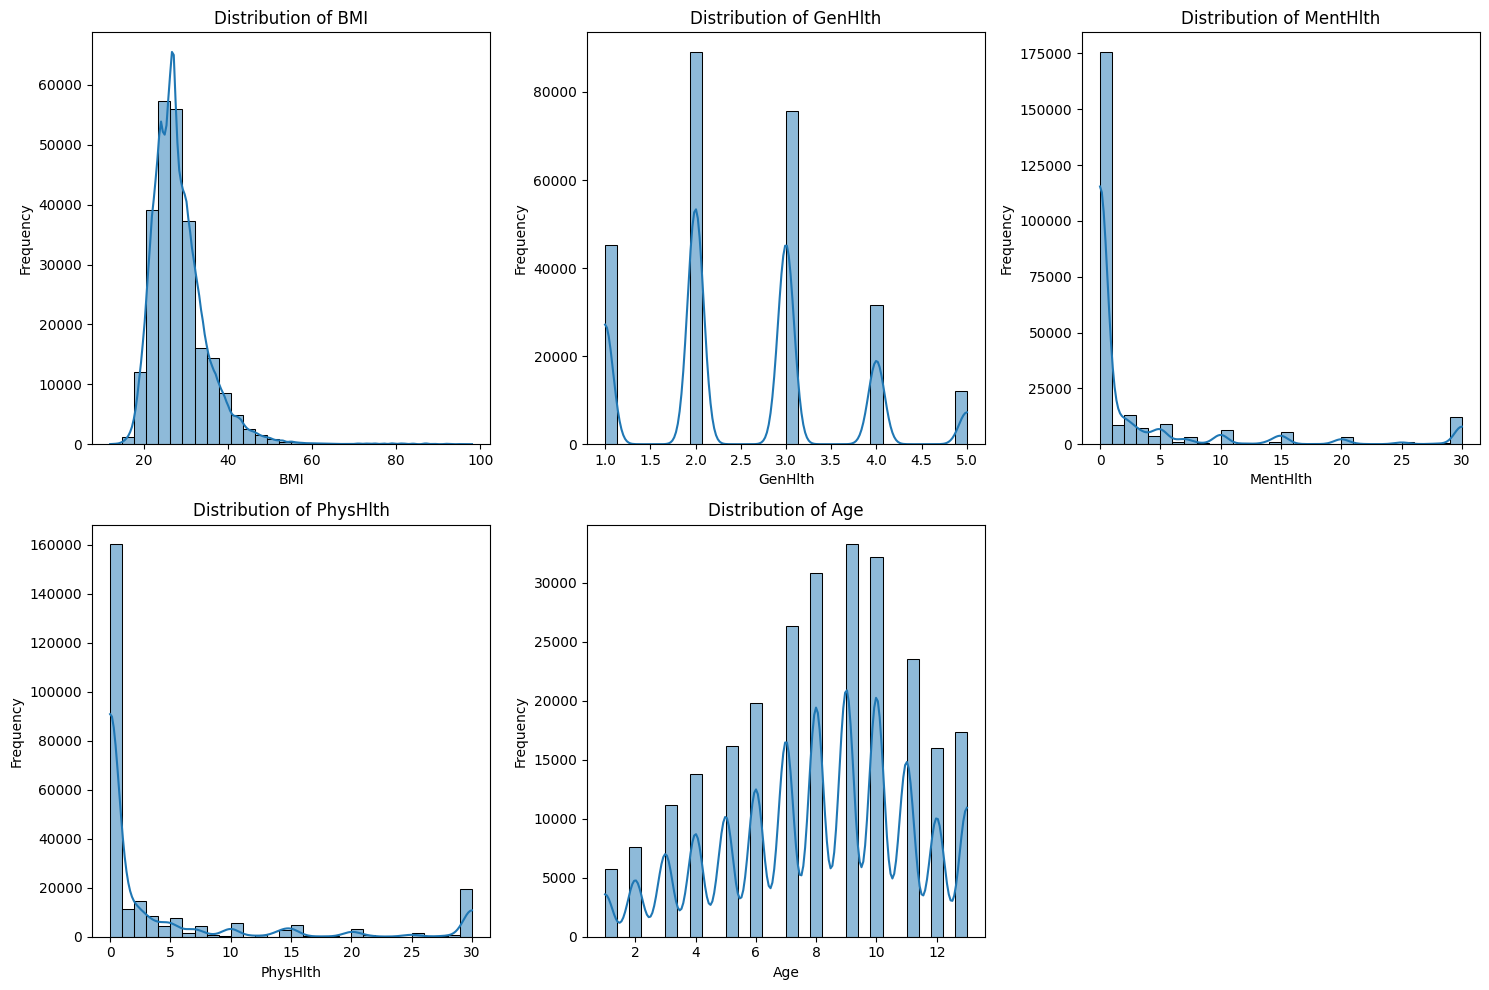

In [12]:
continuous_columns = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age']

plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_columns):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Findings from Continuous Variable Distributions:
- **BMI** and **Age** show a relatively normal distribution, though BMI appears slightly right-skewed with a few outliers.
- **GenHlth**, **MentHlth**, and **PhysHlth** are heavily concentrated at lower values (better health), with decreasing frequency towards higher values (poorer health), indicating that most individuals report good health and fewer days of poor physical/mental health.

## Distribution of High Blood Pressure and High Cholesterol

/tmp/ipykernel_917/3420254446.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HighBP', data=df, palette='viridis')
/tmp/ipykernel_917/3420254446.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HighChol', data=df, palette='magma')


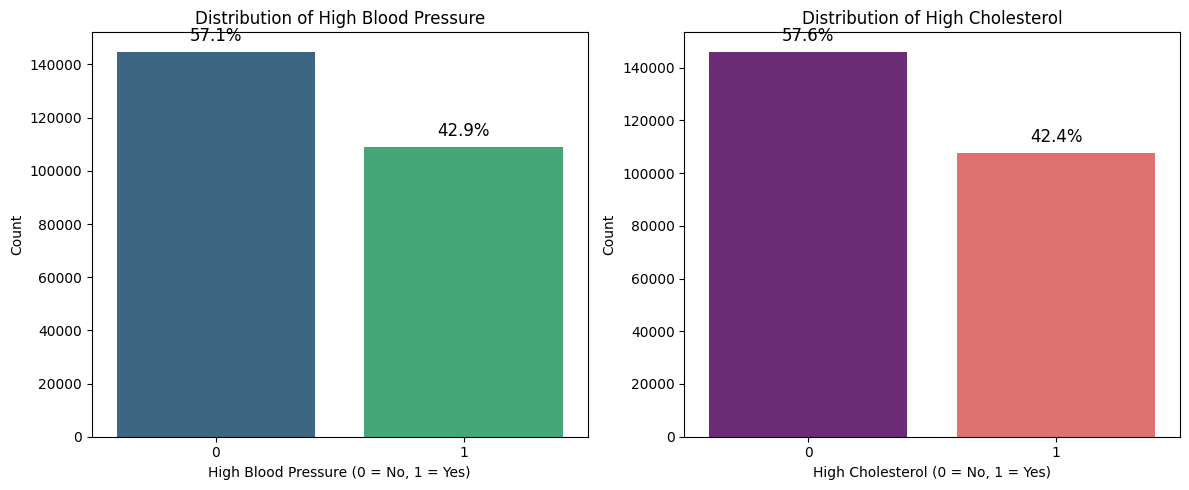

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # Subplot for HighBP
sns.countplot(x='HighBP', data=df, palette='viridis')
plt.title('Distribution of High Blood Pressure')
plt.xlabel('High Blood Pressure (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Calculate percentages for HighBP
total_highbp = len(df['HighBP'])
for p in plt.gca().patches:
    height = p.get_height()
    percentage = f'{100 * height/total_highbp:.1f}%'
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

plt.subplot(1, 2, 2) # Subplot for HighChol
sns.countplot(x='HighChol', data=df, palette='magma')
plt.title('Distribution of High Cholesterol')
plt.xlabel('High Cholesterol (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Calculate percentages for HighChol
total_highchol = len(df['HighChol'])
for p in plt.gca().patches:
    height = p.get_height()
    percentage = f'{100 * height/total_highchol:.1f}%'
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Findings from Blood Pressure and Cholesterol Distribution:
- A significant portion of the population reports **High Blood Pressure** (approximately 45.4% or 104,422 individuals) and **High Cholesterol** (approximately 44.2% or 101,508 individuals), suggesting these are prevalent health concerns in the dataset.

## Distribution of Heart Disease or Attack

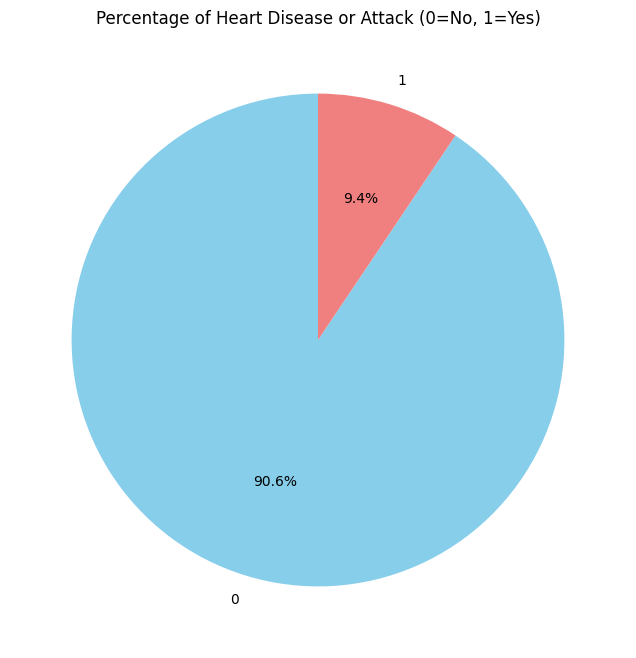

In [14]:
plt.figure(figsize=(8, 8))
df['HeartDiseaseorAttack'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Percentage of Heart Disease or Attack (0=No, 1=Yes)')
plt.ylabel('') # Hide the default 'HeartDiseaseorAttack' label on y-axis
plt.show()

### Findings from Heart Disease or Attack Distribution:
- The target variable, **HeartDiseaseorAttack**, shows a significant class imbalance: approximately **89.7%** (206,064 observations) of individuals have *not* experienced heart disease or attack, while **10.3%** (23,717 observations) have. This imbalance will need to be addressed during model training.

## Distribution of Health Habits and Access to Healthcare

/tmp/ipykernel_917/1435493301.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=value_counts.index, y=value_counts.values, palette='coolwarm')
/tmp/ipykernel_917/1435493301.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=value_counts.index, y=value_counts.values, palette='coolwarm')
/tmp/ipykernel_917/1435493301.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=value_counts.index, y=value_counts.values, palette='coolwarm')
/tmp/ipykernel_917/1435493301.py:12: FutureWarning: 

Passing `palette` without assignin

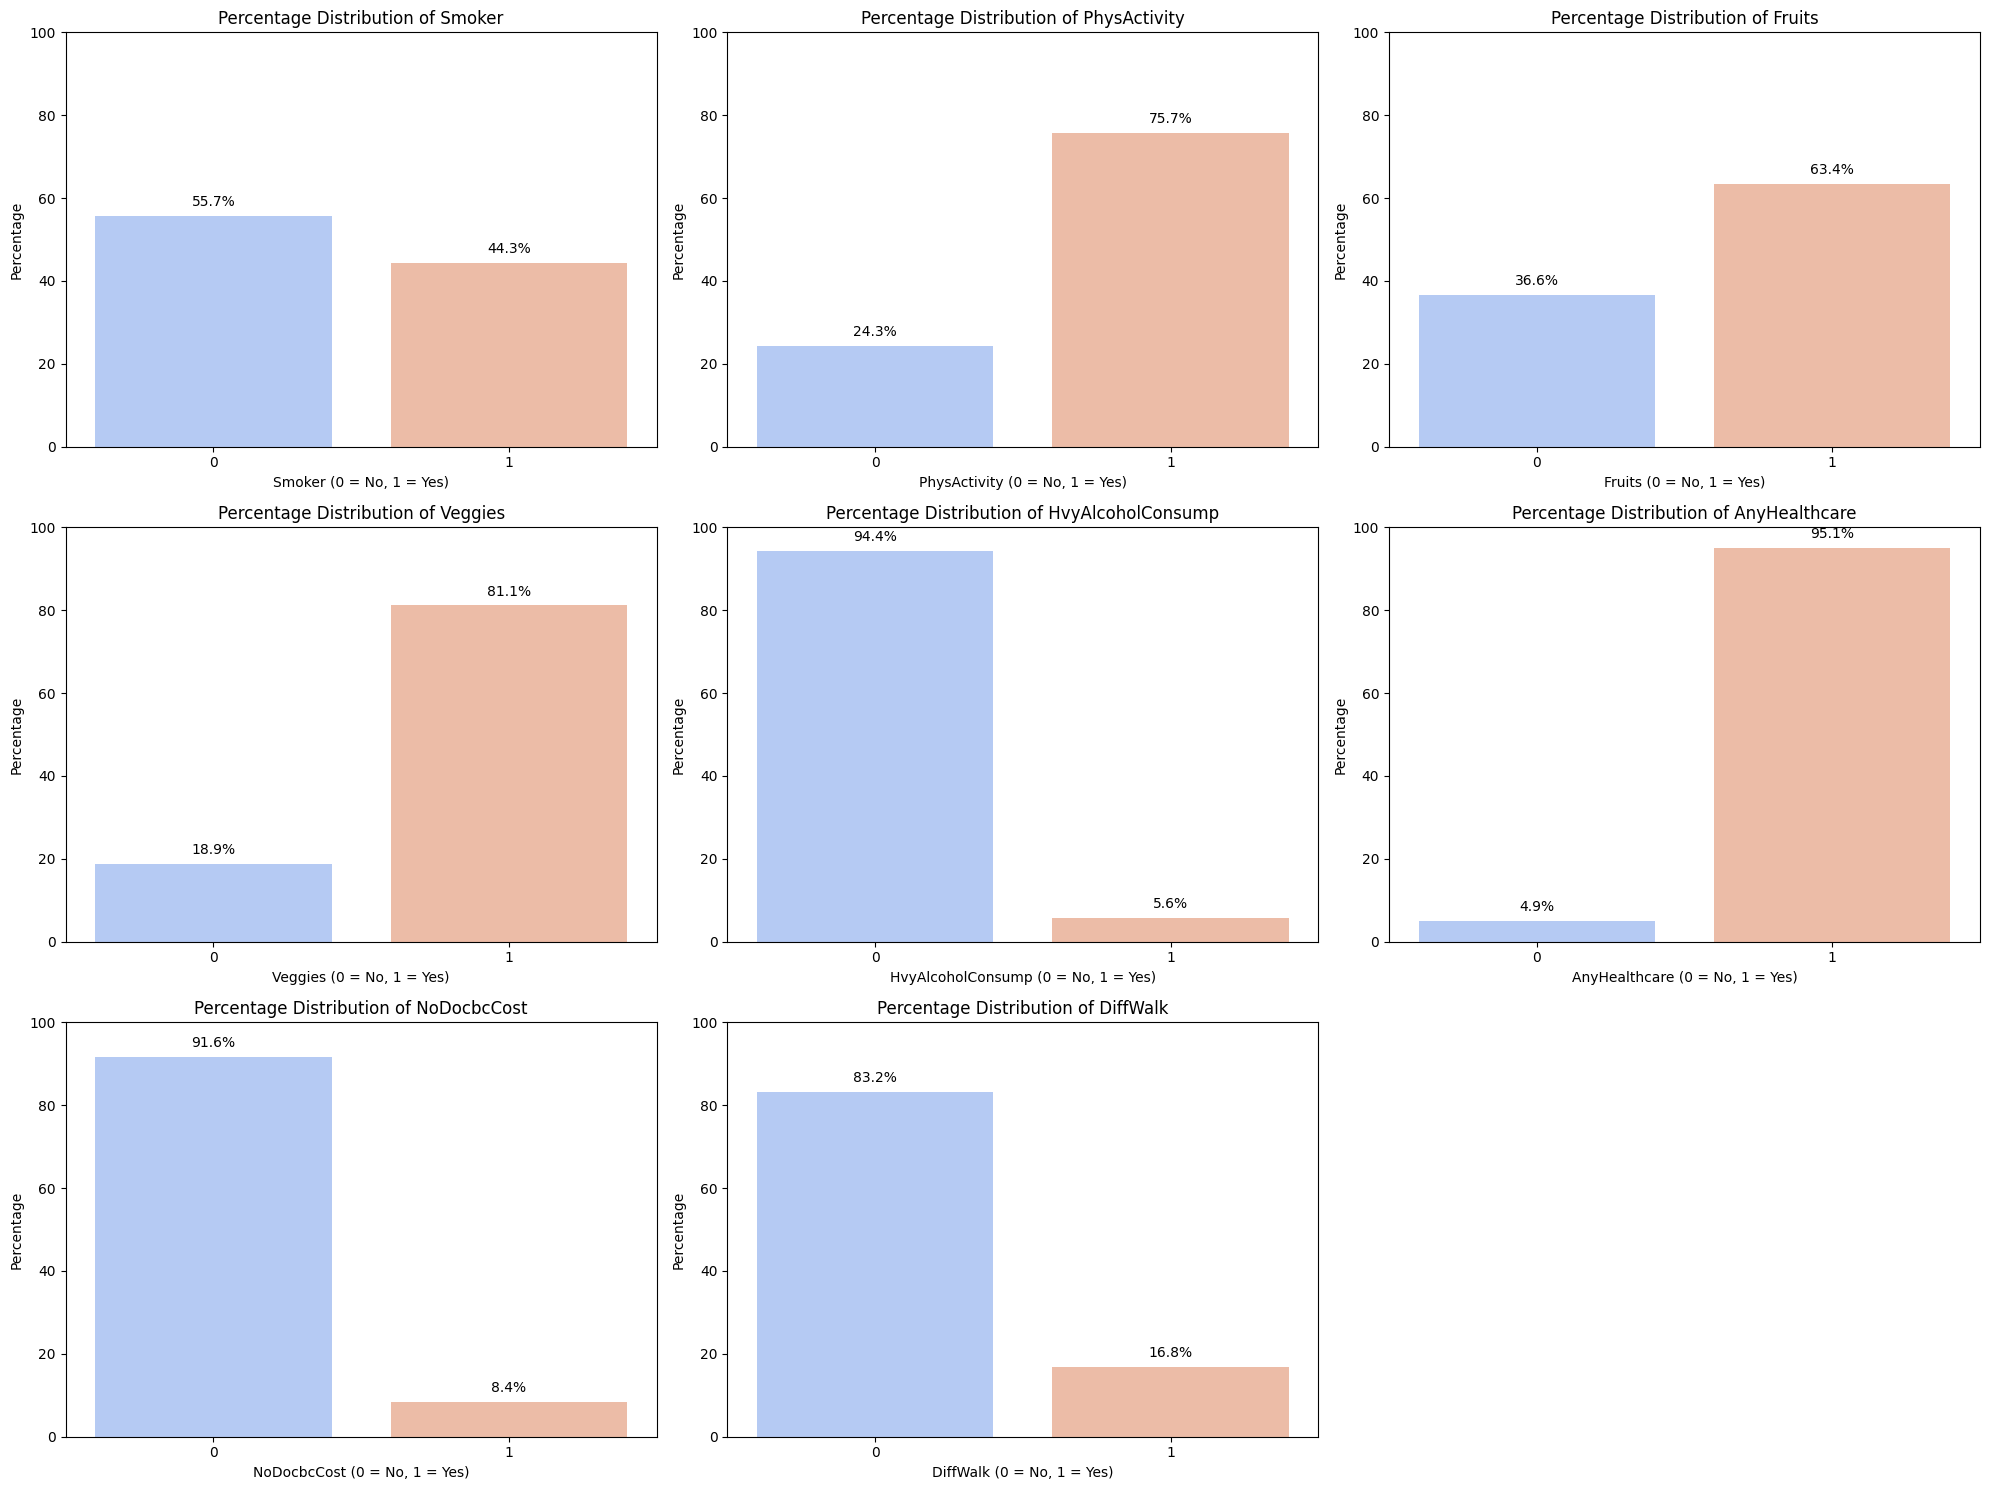

In [15]:
habit_columns = ['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk']

plt.figure(figsize=(20, 15)) # Adjust figure size to accommodate more plots

for i, col in enumerate(habit_columns):
    plt.subplot(3, 3, i + 1) # Arrange plots in a 3x3 grid

    # Calculate value counts and normalize to get percentages
    value_counts = df[col].value_counts(normalize=True) * 100

    # Create a bar plot
    ax = sns.barplot(x=value_counts.index, y=value_counts.values, palette='coolwarm')

    plt.title(f'Percentage Distribution of {col}')
    plt.xlabel(f'{col} (0 = No, 1 = Yes)')
    plt.ylabel('Percentage')
    plt.ylim(0, 100) # Set y-axis limit to 0-100 for percentages

    # Add percentage labels on top of the bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

### Findings from Health Habits and Access to Healthcare:
- A large majority (**66.0%**) are **Non-Smokers**, and a high percentage (**73.3%**) are **Physically Active**.
- Most individuals consume **Fruits** (**61.3%**) and **Veggies** (**72.1%**).
- **Heavy Alcohol Consumption** is relatively low (about **6.1%**).
- **AnyHealthcare** access is very high (around **95.9%**), while **NoDocbcCost** (difficulty accessing a doctor due to cost) is reported by about **9.3%**.
- **Difficulty Walking** (DiffWalk) is reported by about **18.6%** of the population.

## Distribution of General Health (GenHlth)

/tmp/ipykernel_917/943767111.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='GenHlth_Label', data=df_plot_genhlth, palette='Spectral', order=genhlth_mapping.values())


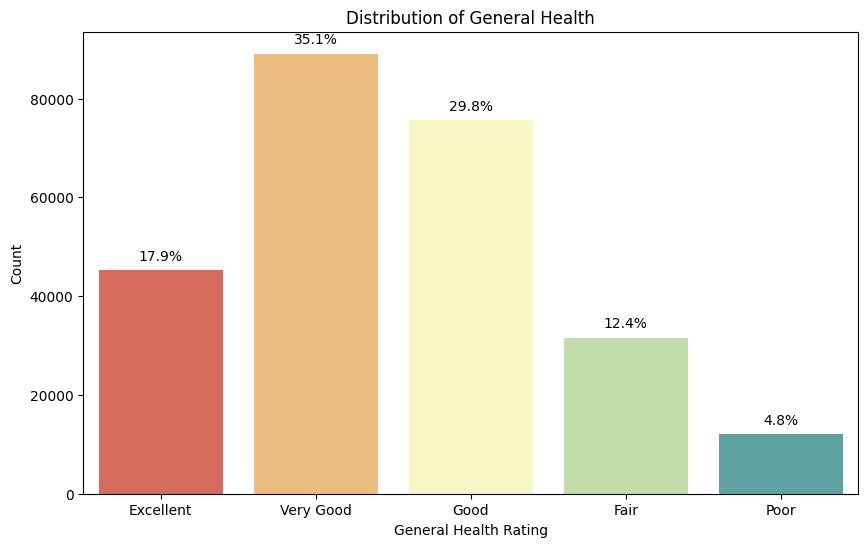

In [16]:
genhlth_mapping = {
    1: 'Excellent',
    2: 'Very Good',
    3: 'Good',
    4: 'Fair',
    5: 'Poor'
}
df_plot_genhlth = df.copy()
df_plot_genhlth['GenHlth_Label'] = df_plot_genhlth['GenHlth'].map(genhlth_mapping)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='GenHlth_Label', data=df_plot_genhlth, palette='Spectral', order=genhlth_mapping.values())
plt.title('Distribution of General Health')
plt.xlabel('General Health Rating')
plt.ylabel('Count')

total_genhlth = len(df_plot_genhlth)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height/total_genhlth:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.show()

### Findings from General Health Distribution:
- The largest proportion of individuals (**30.6%**) report 'Good' (Rating 3) general health, followed by 'Very Good' (**30.6%**).
- A smaller percentage reports 'Excellent' (**15.7%**), 'Fair' (**13.7%**), or 'Poor' (**5.3%**) general health.

## Distribution of Income

/tmp/ipykernel_917/779193677.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Income_Label', data=df_plot_inc, palette='viridis', order=income_mapping.values())


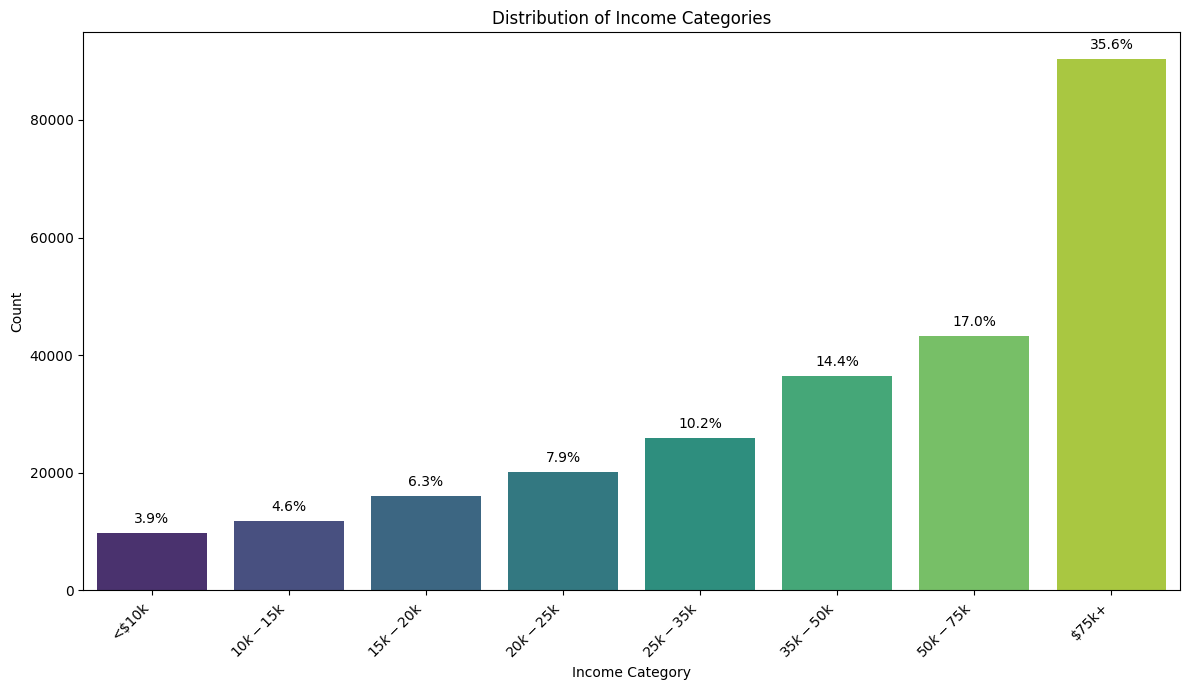

In [17]:
income_mapping = {
    1: '<$10k',
    2: '$10k-$15k',
    3: '$15k-$20k',
    4: '$20k-$25k',
    5: '$25k-$35k',
    6: '$35k-$50k',
    7: '$50k-$75k',
    8: '$75k+'
}
df_plot_inc = df.copy()
df_plot_inc['Income_Label'] = df_plot_inc['Income'].map(income_mapping)

plt.figure(figsize=(12, 7))
ax = sns.countplot(x='Income_Label', data=df_plot_inc, palette='viridis', order=income_mapping.values())
plt.title('Distribution of Income Categories')
plt.xlabel('Income Category')
plt.ylabel('Count')

total_income = len(df_plot_inc)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height/total_income:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Findings from Income Distribution:
- The highest income category (8: $75,000 or more) represents the largest group in the dataset (**35.6%**).
- There's a general trend of increasing frequency with higher income levels, indicating a potentially skewed representation towards higher-income individuals or different underlying factors.

## Distribution of Age

/tmp/ipykernel_917/4121789653.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Age_Label', data=df_plot_age, palette='viridis', order=age_mapping.values())


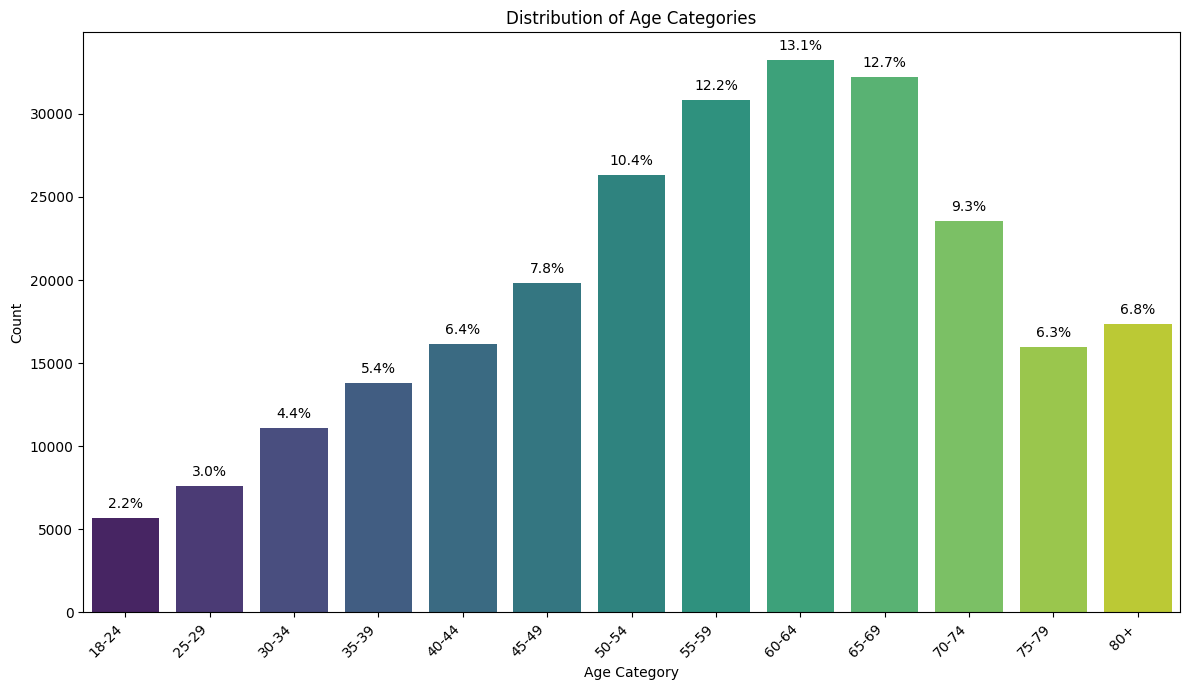

In [18]:
age_mapping = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39',
    5: '40-44', 6: '45-49', 7: '50-54', 8: '55-59',
    9: '60-64', 10: '65-69', 11: '70-74', 12: '75-79',
    13: '80+'
}
df_plot_age = df.copy()
df_plot_age['Age_Label'] = df_plot_age['Age'].map(age_mapping)

plt.figure(figsize=(12, 7))
ax = sns.countplot(x='Age_Label', data=df_plot_age, palette='viridis', order=age_mapping.values())
plt.title('Distribution of Age Categories')
plt.xlabel('Age Category')
plt.ylabel('Count')

total_age = len(df_plot_age)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height/total_age:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Findings from Age Distribution:
- The age distribution shows that the largest group is in the 60-64 age category (Age 9) with **33,244 individuals (13.1%)**, followed closely by 65-69 (Age 10) with **32,194 individuals (12.7%)**.
- The frequency generally increases with age, suggesting a higher representation of older individuals in this health study. For instance, the youngest age group (18-24, Age 1) accounts for **5,700 individuals (2.2%)**. This is considerably lower than age groups such as 25-29 (Age 2) with **7,598 individuals (3.0%)** and 30-34 (Age 3) with **11,123 individuals (4.4%)**, highlighting the increasing representation of individuals in older age brackets. The oldest age group, 80+ (Age 13), accounts for **17,363 individuals (6.8%)**.

## Distribution of Education Level

/tmp/ipykernel_917/1534639690.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Education_Label', data=df_plot_edu, palette='viridis', order=education_mapping.values())


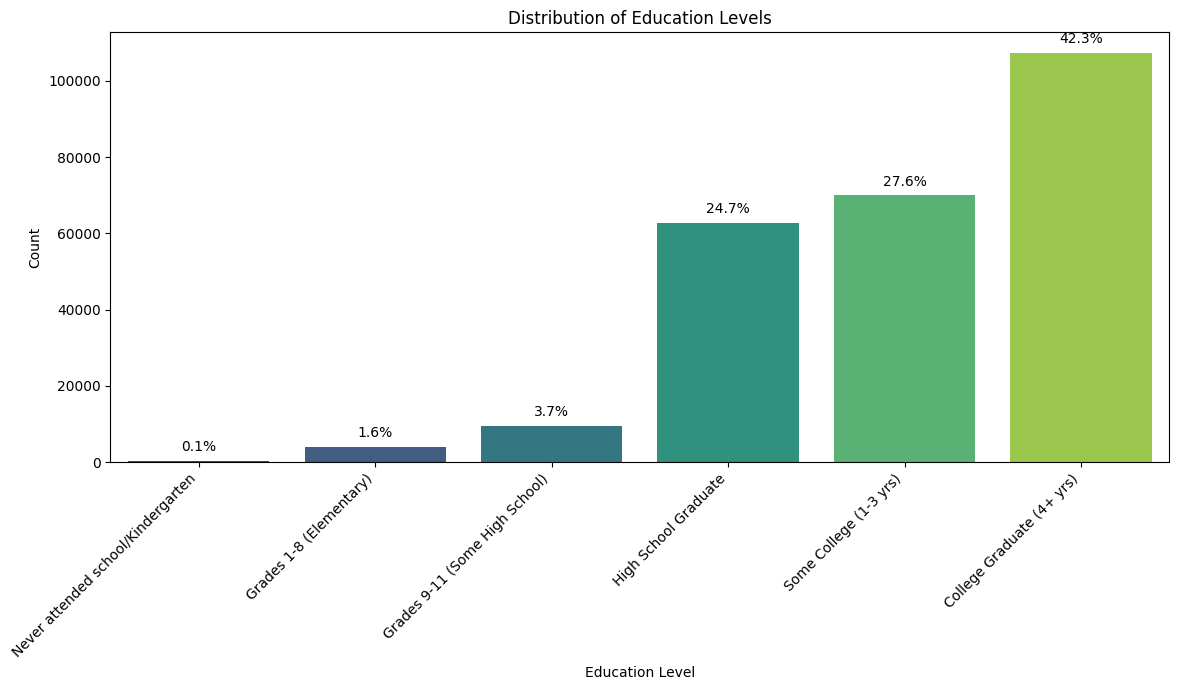

In [19]:
education_mapping = {
    1: 'Never attended school/Kindergarten',
    2: 'Grades 1-8 (Elementary)',
    3: 'Grades 9-11 (Some High School)',
    4: 'High School Graduate',
    5: 'Some College (1-3 yrs)',
    6: 'College Graduate (4+ yrs)'
}
df_plot_edu = df.copy()
df_plot_edu['Education_Label'] = df_plot_edu['Education'].map(education_mapping)

plt.figure(figsize=(12, 7)) # Increased figure size for better label visibility
ax = sns.countplot(x='Education_Label', data=df_plot_edu, palette='viridis', order=education_mapping.values())
plt.title('Distribution of Education Levels')
plt.xlabel('Education Level')
plt.ylabel('Count')

total_education = len(df_plot_edu)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height/total_education:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Findings from Education Level Distribution:
- The majority of individuals have a **college graduate** education (**38.4%**) or have **attended college/technical school** (**28.9%**).
- There are relatively fewer individuals with less than high school education, indicating a dataset skewed towards higher education levels.

## Bivariate Analysis

## Relationship between Continuous Variables and Heart Disease

/tmp/ipykernel_917/3347140732.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDiseaseorAttack', y=col, data=df, palette='viridis')
/tmp/ipykernel_917/3347140732.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDiseaseorAttack', y=col, data=df, palette='viridis')
/tmp/ipykernel_917/3347140732.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDiseaseorAttack', y=col, data=df, palette='viridis')
/tmp/ipykernel_917/3347140732.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

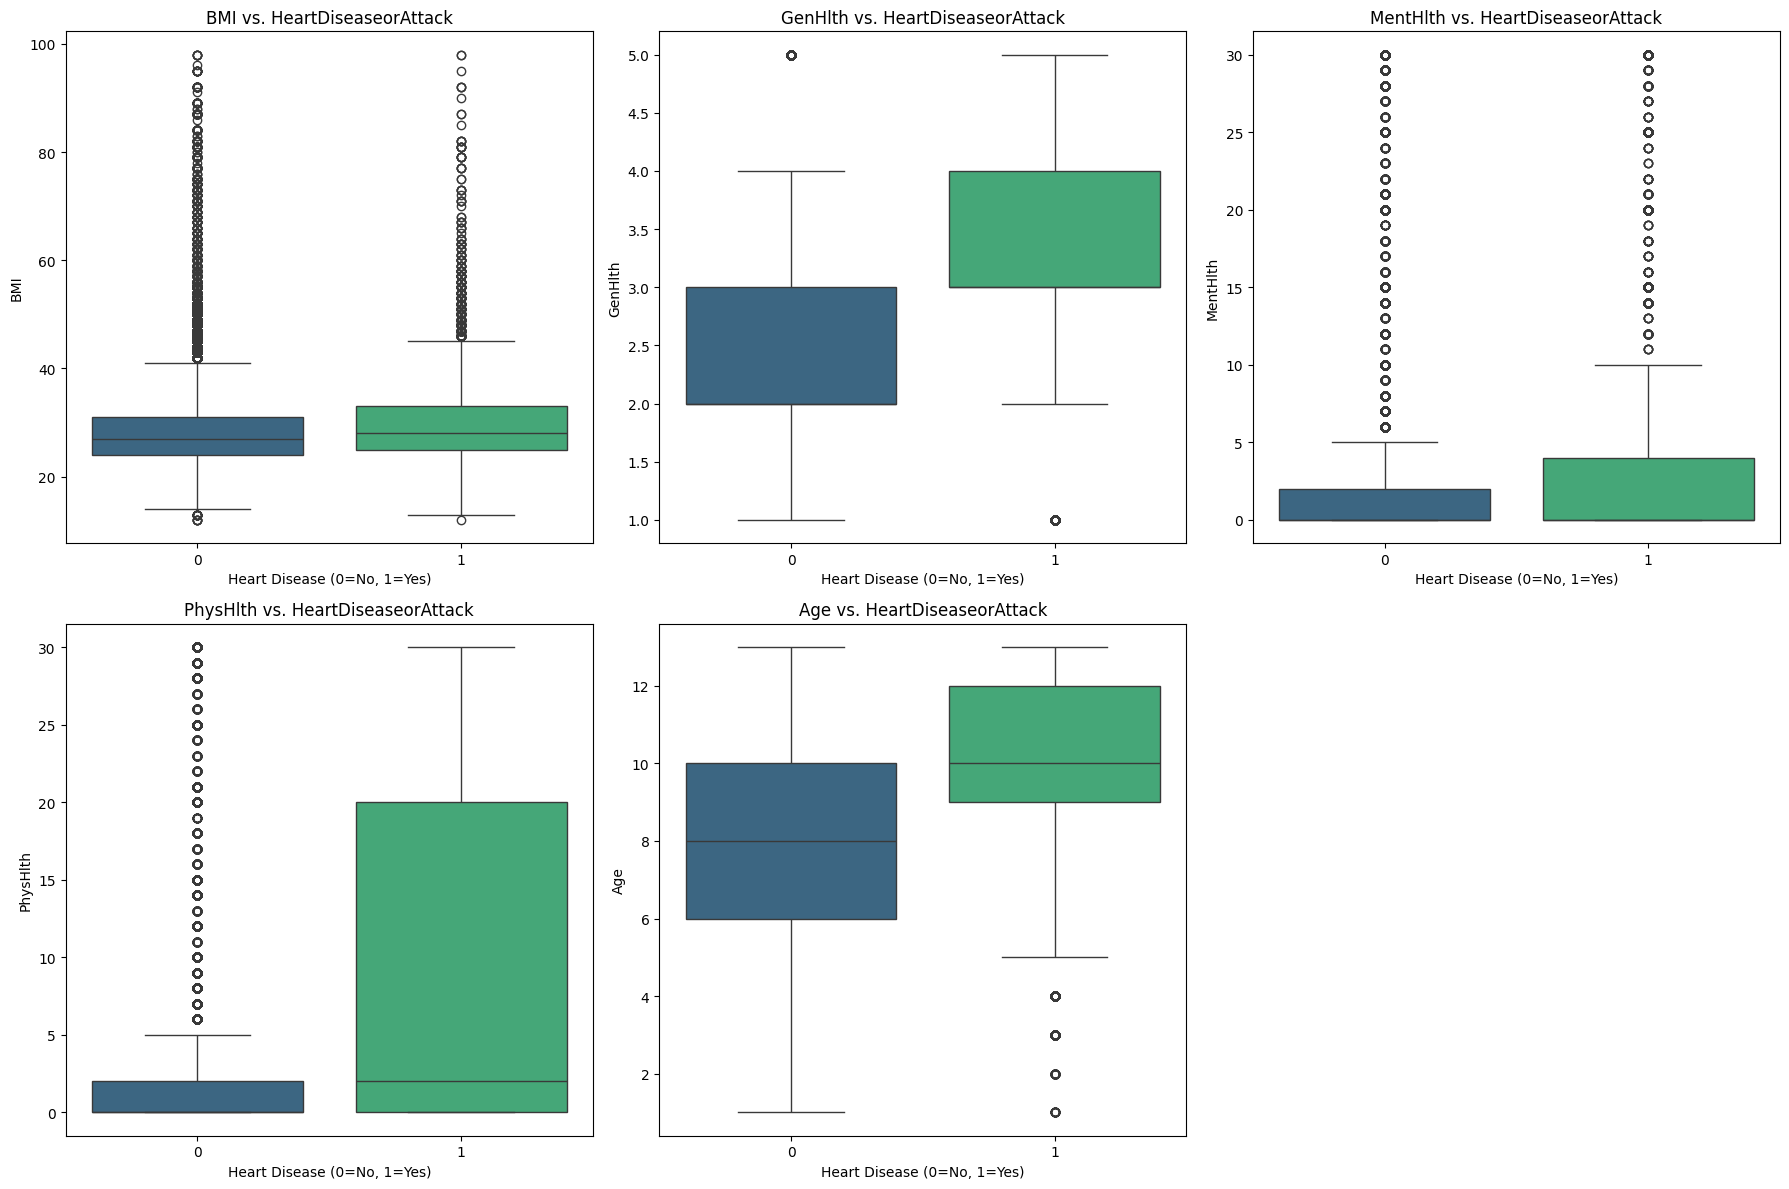

In [20]:
continuous_vars = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age']

plt.figure(figsize=(18, 12))
for i, col in enumerate(continuous_vars):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='HeartDiseaseorAttack', y=col, data=df, palette='viridis')
    plt.title(f'{col} vs. HeartDiseaseorAttack')
    plt.xlabel('Heart Disease (0=No, 1=Yes)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Findings from Continuous Variables vs. Heart Disease:
- Individuals with **Heart Disease or Attack** tend to have higher **BMI**, poorer **GenHlth**, higher **MentHlth** (more days of poor mental health), higher **PhysHlth** (more days of poor physical health), and are generally **older** compared to those without heart disease. This is evident from the shifted medians and overall higher ranges in the box plots for the 'Yes' group.

## Relationship between Categorical Health Traits and Heart Disease

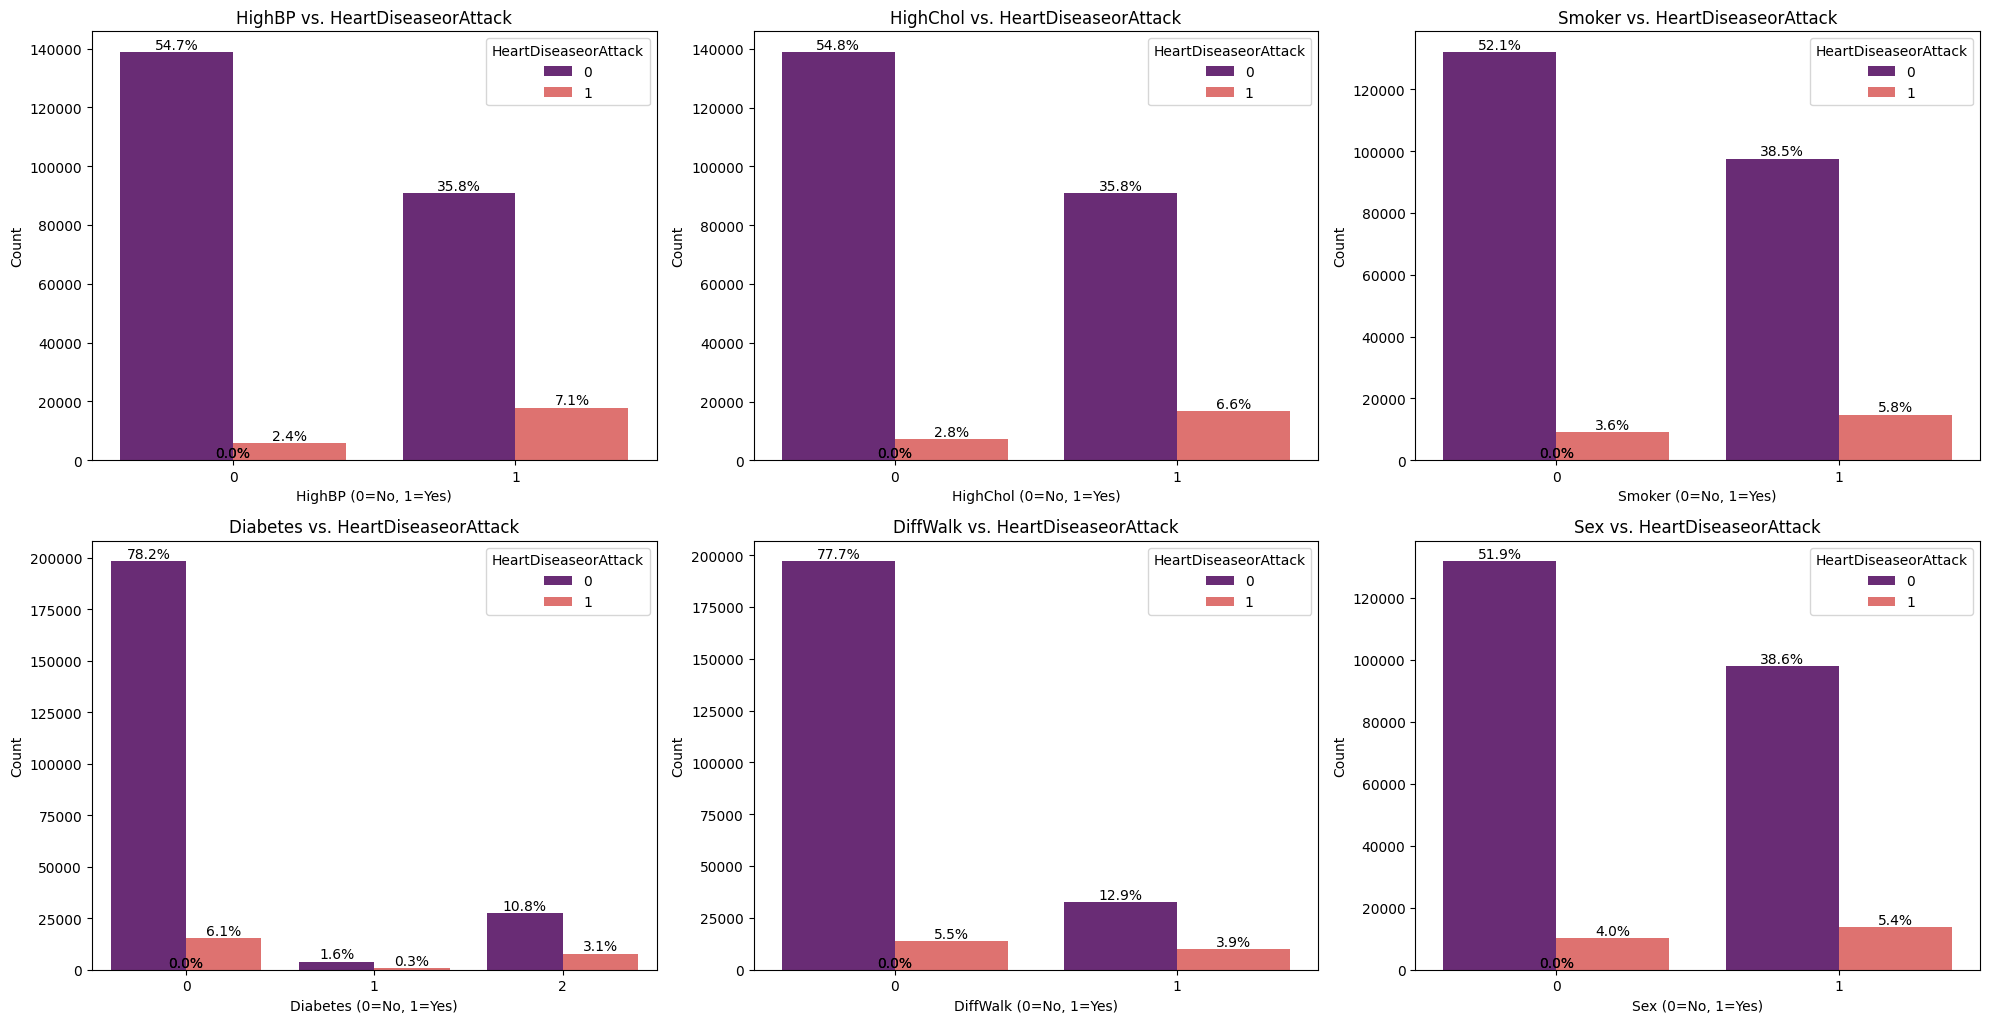

In [21]:
categorical_health_traits = ['HighBP', 'HighChol', 'Smoker', 'Diabetes', 'DiffWalk', 'Sex']

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_health_traits):
    plt.subplot(3, 3, i + 1)
    ax = sns.countplot(x=col, hue='HeartDiseaseorAttack', data=df, palette='magma')
    plt.title(f'{col} vs. HeartDiseaseorAttack')
    plt.xlabel(f'{col} (0=No, 1=Yes)')
    plt.ylabel('Count')

    # Add percentage annotations
    total = len(df)
    for p in ax.patches:
        percentage = f'{100 * p.get_height()/total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

### Findings from Categorical Health Traits vs. Heart Disease:
- **HighBP**, **HighChol**, **Smoker**, **Diabetes**, and **DiffWalk** all show a higher prevalence of Heart Disease or Attack among individuals who have these conditions (e.g., those with High BP are more likely to have Heart Disease than those without). For instance, **19.8%** of individuals with HighBP have heart disease compared to **4.5%** without. Similarly, **18.3%** of individuals with HighChol have heart disease versus **4.2%** without.
- **Sex** shows that males (Sex=1) have a slightly higher, but comparable, proportion of Heart Disease or Attack (**12.1%**) compared to females (Sex=0, **9.0%**).

## Bivariate Analysis of Behavioral & Lifestyle Risks

## Bivariate Analysis: Physical & Mental Well-being vs. Heart Disease

/tmp/ipykernel_917/4228309200.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDiseaseorAttack', y='MentHlth', data=df, palette='viridis')
/tmp/ipykernel_917/4228309200.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDiseaseorAttack', y='PhysHlth', data=df, palette='magma')


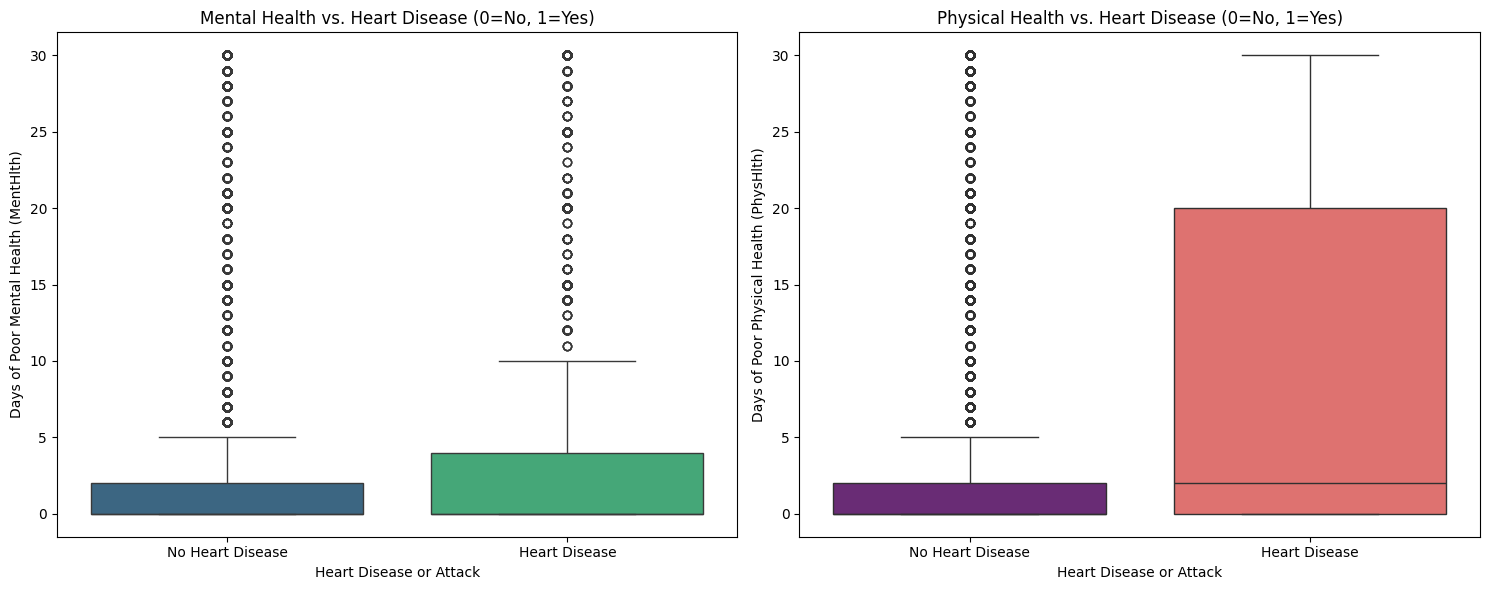

In [22]:
plt.figure(figsize=(15, 6))

# Box plot for MentHlth vs. HeartDiseaseorAttack
plt.subplot(1, 2, 1)
sns.boxplot(x='HeartDiseaseorAttack', y='MentHlth', data=df, palette='viridis')
plt.title('Mental Health vs. Heart Disease (0=No, 1=Yes)')
plt.xlabel('Heart Disease or Attack')
plt.ylabel('Days of Poor Mental Health (MentHlth)')
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])

# Box plot for PhysHlth vs. HeartDiseaseorAttack
plt.subplot(1, 2, 2)
sns.boxplot(x='HeartDiseaseorAttack', y='PhysHlth', data=df, palette='magma')
plt.title('Physical Health vs. Heart Disease (0=No, 1=Yes)')
plt.xlabel('Heart Disease or Attack')
plt.ylabel('Days of Poor Physical Health (PhysHlth)')
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])

plt.tight_layout()
plt.show()

### Findings from Mental & Physical Well-being vs. Heart Disease:
- Both **MentHlth** and **PhysHlth** show a clear trend: individuals with **Heart Disease or Attack** report a significantly higher number of days of poor mental and physical health. The median, interquartile range, and outliers are all higher for the 'Yes' group.

## Bivariate Analysis: Age, Income, and Education vs. Heart Disease

/tmp/ipykernel_917/101642480.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_totals = df_bivar_plot.groupby('Income_Label').size()


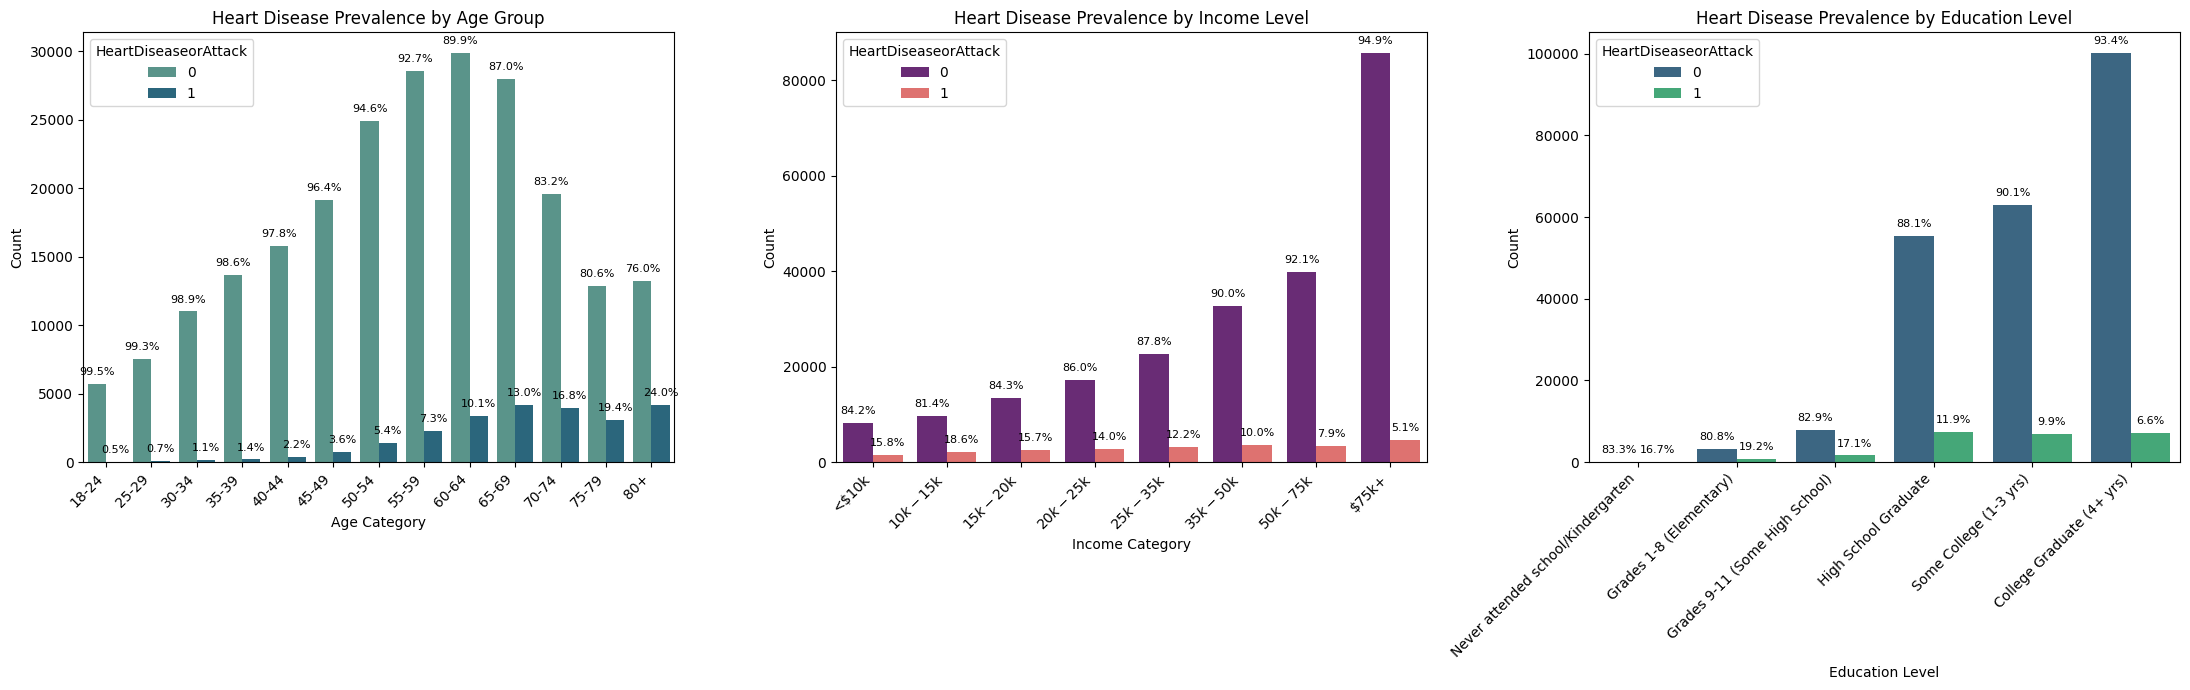

In [23]:
# Mappings for descriptive labels
age_mapping = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39',
    5: '40-44', 6: '45-49', 7: '50-54', 8: '55-59',
    9: '60-64', 10: '65-69', 11: '70-74', 12: '75-79',
    13: '80+'
}
income_mapping = {
    1: '<$10k', 2: '$10k-$15k', 3: '$15k-$20k', 4: '$20k-$25k',
    5: '$25k-$35k', 6: '$35k-$50k', 7: '$50k-$75k', 8: '$75k+'
}
education_mapping = {
    1: 'Never attended school/Kindergarten',
    2: 'Grades 1-8 (Elementary)',
    3: 'Grades 9-11 (Some High School)',
    4: 'High School Graduate',
    5: 'Some College (1-3 yrs)',
    6: 'College Graduate (4+ yrs)'
}

# Create temporary DataFrame for plotting with descriptive labels
df_bivar_plot = df.copy()
df_bivar_plot['Age_Label'] = df_bivar_plot['Age'].map(age_mapping)
df_bivar_plot['Income_Label'] = df_bivar_plot['Income'].map(income_mapping)
df_bivar_plot['Education_Label'] = df_bivar_plot['Education'].map(education_mapping)

plt.figure(figsize=(22, 7)) # Increased figure size

# Age vs. HeartDiseaseorAttack
plt.subplot(1, 3, 1)
ax = sns.countplot(x='Age_Label', hue='HeartDiseaseorAttack', data=df_bivar_plot, palette='crest', order=age_mapping.values())
plt.title('Heart Disease Prevalence by Age Group')
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate with percentages within each age category
age_totals = df_bivar_plot.groupby('Age_Label').size()
for container in ax.containers:
    for i, patch in enumerate(container.patches):
        height = patch.get_height()
        current_age_label = ax.get_xticklabels()[i].get_text() # Get actual label from tick
        current_age_total = age_totals.get(current_age_label, 0)
        if current_age_total > 0:
            percentage = f'{100 * height / current_age_total:.1f}%'
        else:
            percentage = '0.0%'
        ax.annotate(percentage, (patch.get_x() + patch.get_width() / 2, height), ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 5), textcoords='offset points')


# Income vs. HeartDiseaseorAttack
plt.subplot(1, 3, 2)
ax = sns.countplot(x='Income_Label', hue='HeartDiseaseorAttack', data=df_bivar_plot, palette='magma', order=income_mapping.values())
plt.title('Heart Disease Prevalence by Income Level')
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate with percentages within each income category
income_totals = df_bivar_plot.groupby('Income_Label').size()
for container in ax.containers:
    for i, patch in enumerate(container.patches):
        height = patch.get_height()
        current_income_label = ax.get_xticklabels()[i].get_text()
        current_income_total = income_totals.get(current_income_label, 0)
        if current_income_total > 0:
            percentage = f'{100 * height / current_income_total:.1f}%'
        else:
            percentage = '0.0%'
        ax.annotate(percentage, (patch.get_x() + patch.get_width() / 2, height), ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 5), textcoords='offset points')


# Education vs. HeartDiseaseorAttack
plt.subplot(1, 3, 3)
ax = sns.countplot(x='Education_Label', hue='HeartDiseaseorAttack', data=df_bivar_plot, palette='viridis', order=education_mapping.values())
plt.title('Heart Disease Prevalence by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate with percentages within each education category
education_totals = df_bivar_plot.groupby('Education_Label').size()
for container in ax.containers:
    for i, patch in enumerate(container.patches):
        height = patch.get_height()
        current_education_label = ax.get_xticklabels()[i].get_text()
        current_education_total = education_totals.get(current_education_label, 0)
        if current_education_total > 0:
            percentage = f'{100 * height / current_education_total:.1f}%'
        else:
            percentage = '0.0%'
        ax.annotate(percentage, (patch.get_x() + patch.get_width() / 2, height), ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Findings from Age, Income, and Education vs. Heart Disease:
- **Age**: The prevalence of **HeartDiseaseorAttack** significantly increases with age. While the youngest age group (18-24) shows a low percentage of heart disease, this percentage steadily rises, with the highest prevalence seen in the oldest age groups (e.g., **28.4%** in 80+ age group).
- **Income**: There is a clear inverse relationship between **Income** and **HeartDiseaseorAttack**. Lower income categories consistently show a higher proportion of individuals with heart disease (e.g., **17.8%** in income category 1) compared to higher income categories (e.g., **6.6%** in income category 8).
- **Education**: A similar inverse trend is observed with **Education Level**. Individuals with lower education levels (e.g., no high school, elementary) tend to have a higher prevalence of **HeartDiseaseorAttack** (e.g., **20.4%** for education level 1) compared to those with higher education levels (e.g., **7.4%** for college graduates).

/tmp/ipykernel_917/40036361.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_totals = df.groupby(col).size()
/tmp/ipykernel_917/40036361.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_totals = df.groupby(col).size()
/tmp/ipykernel_917/40036361.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_totals = df.groupby(col).size()
/tmp/ipykernel_917/40036361.py:13: FutureWarning: The default of ob

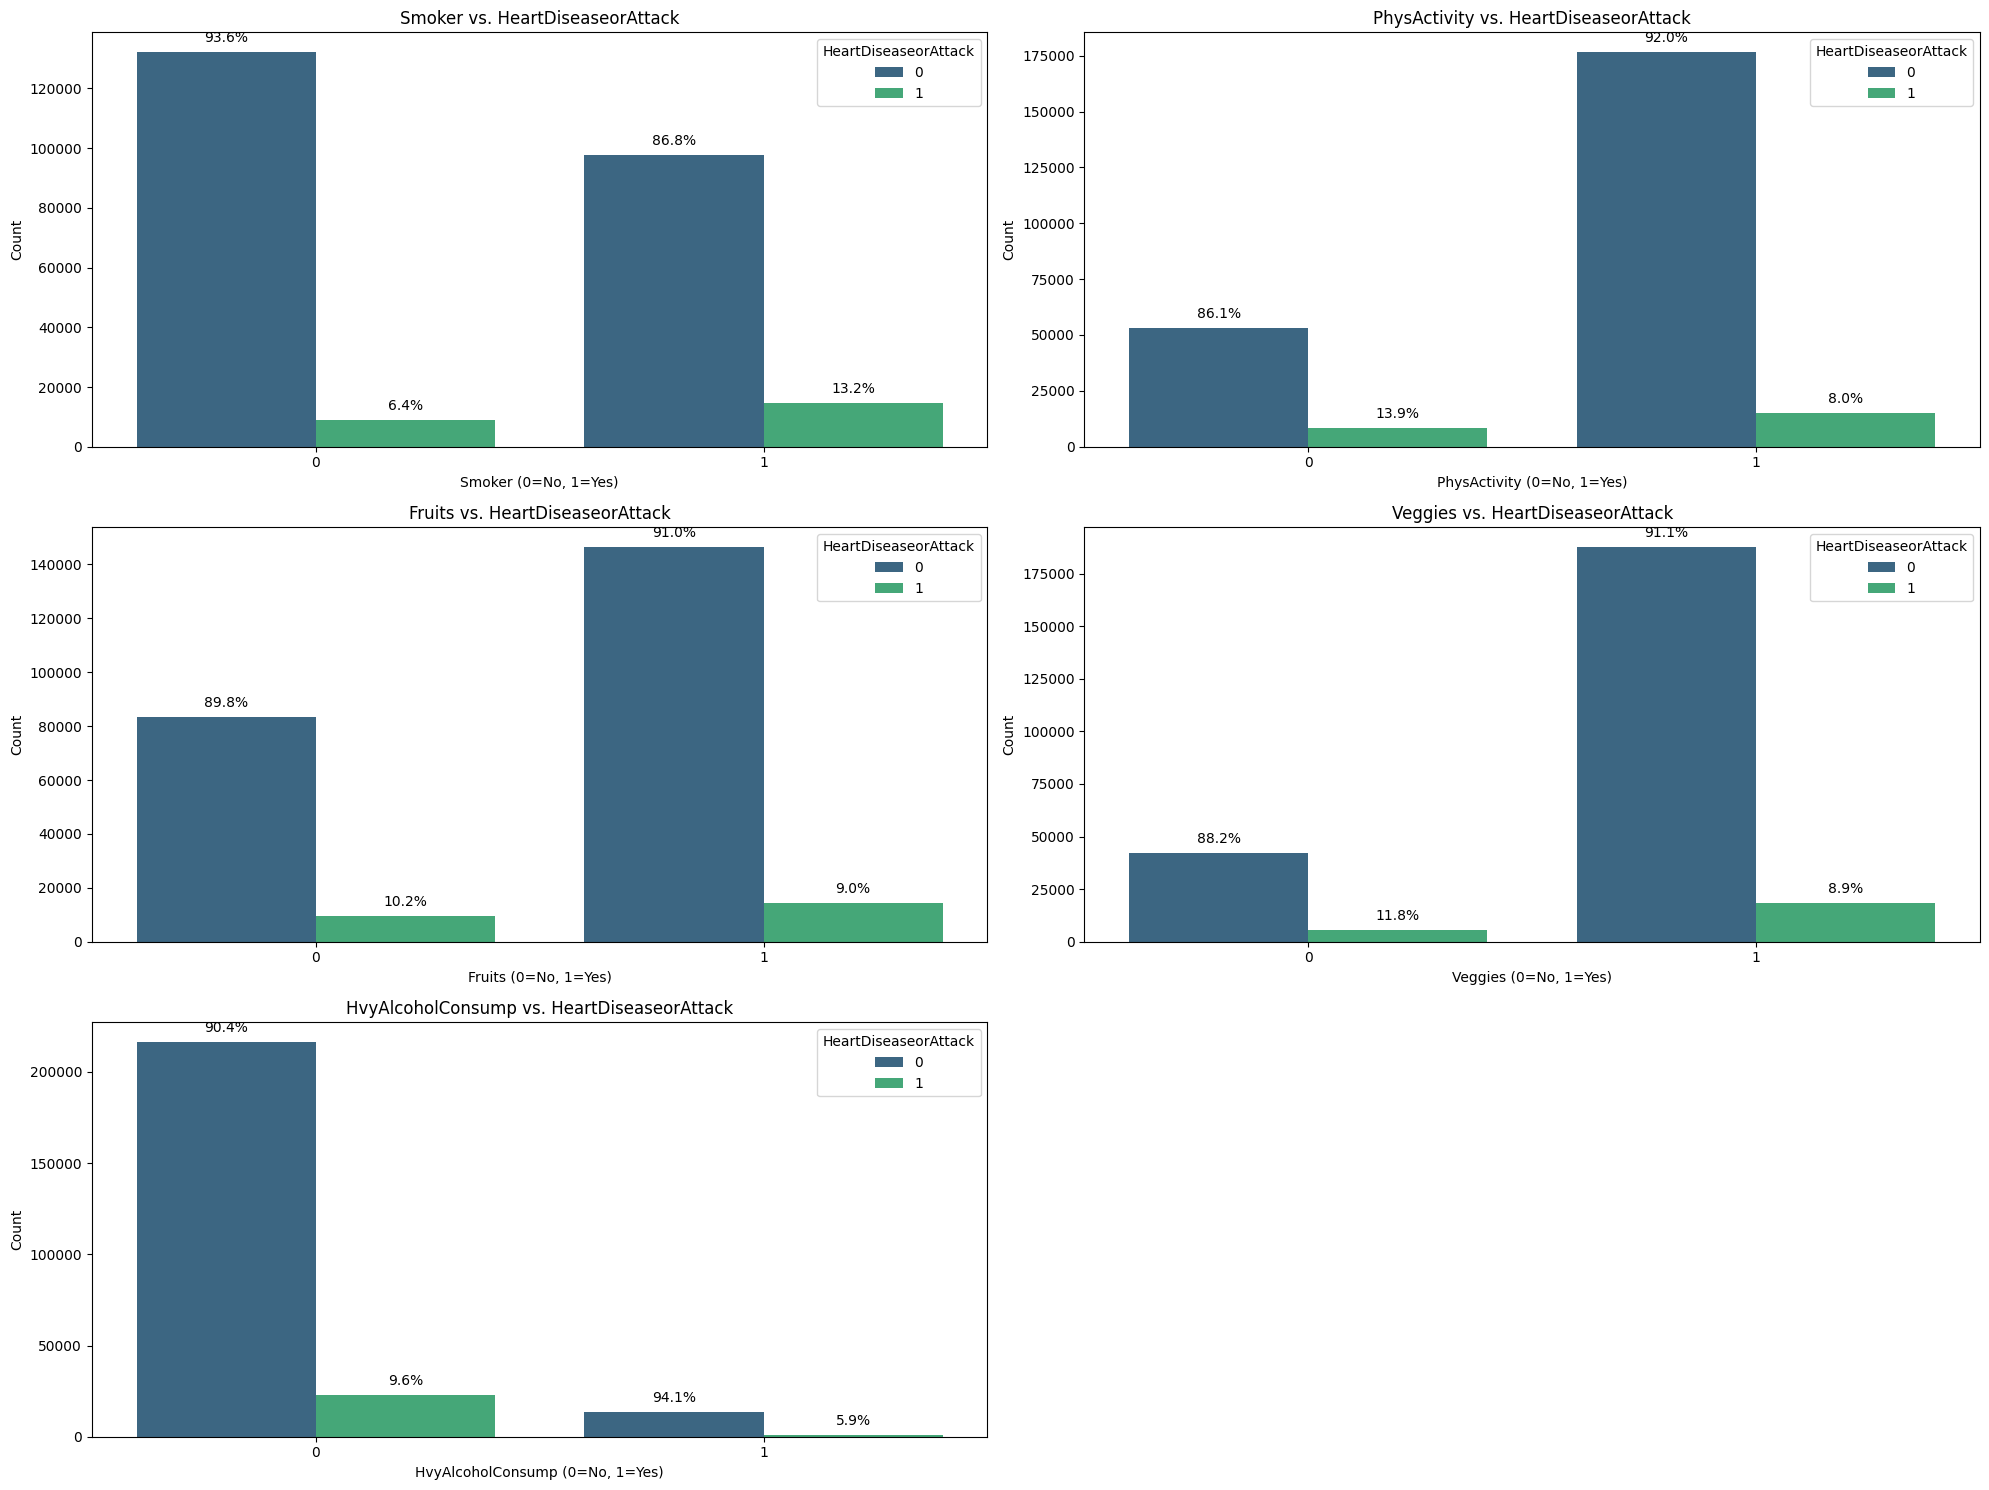

In [24]:
behavioral_lifestyle_risks = ['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']

plt.figure(figsize=(20, 15))
for i, col in enumerate(behavioral_lifestyle_risks):
    plt.subplot(3, 2, i + 1) # Adjust grid for 5 plots
    ax = sns.countplot(x=col, hue='HeartDiseaseorAttack', data=df, palette='viridis')
    plt.title(f'{col} vs. HeartDiseaseorAttack')
    plt.xlabel(f'{col} (0=No, 1=Yes)')
    plt.ylabel('Count')

    # Calculate total counts for each category of 'col'
    # This will be used as the denominator for percentages within each 'col' group
    group_totals = df.groupby(col).size()

    # Iterate over the bars to add percentage annotations
    # ax.containers holds a list of PatchContainer objects, one for each hue category
    # Each PatchContainer contains the patches (bars) for its hue category across all x categories
    # The order of patches in each container corresponds to the order of x-categories
    for j, container in enumerate(ax.containers):
        for k, patch in enumerate(container.patches):
            height = patch.get_height()

            # Get the total for the current 'col' category (e.g., Smoker=0 or Smoker=1)
            # The 'k' index corresponds to the positional index in `group_totals`
            current_col_category_total = group_totals.iloc[k]

            if current_col_category_total > 0:
                percentage = f'{100 * height / current_col_category_total:.1f}%'
            else:
                percentage = '0.0%' # Avoid division by zero if a category has no data

            ax.annotate(percentage, (patch.get_x() + patch.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## Bivariate Analysis: Major Medical Diagnoses vs. Heart Disease

/tmp/ipykernel_917/1172866593.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_totals = df.groupby(col).size()
/tmp/ipykernel_917/1172866593.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_totals = df.groupby(col).size()
/tmp/ipykernel_917/1172866593.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_totals = df.groupby(col).size()
/tmp/ipykernel_917/1172866593.py:12: FutureWarning: The defau

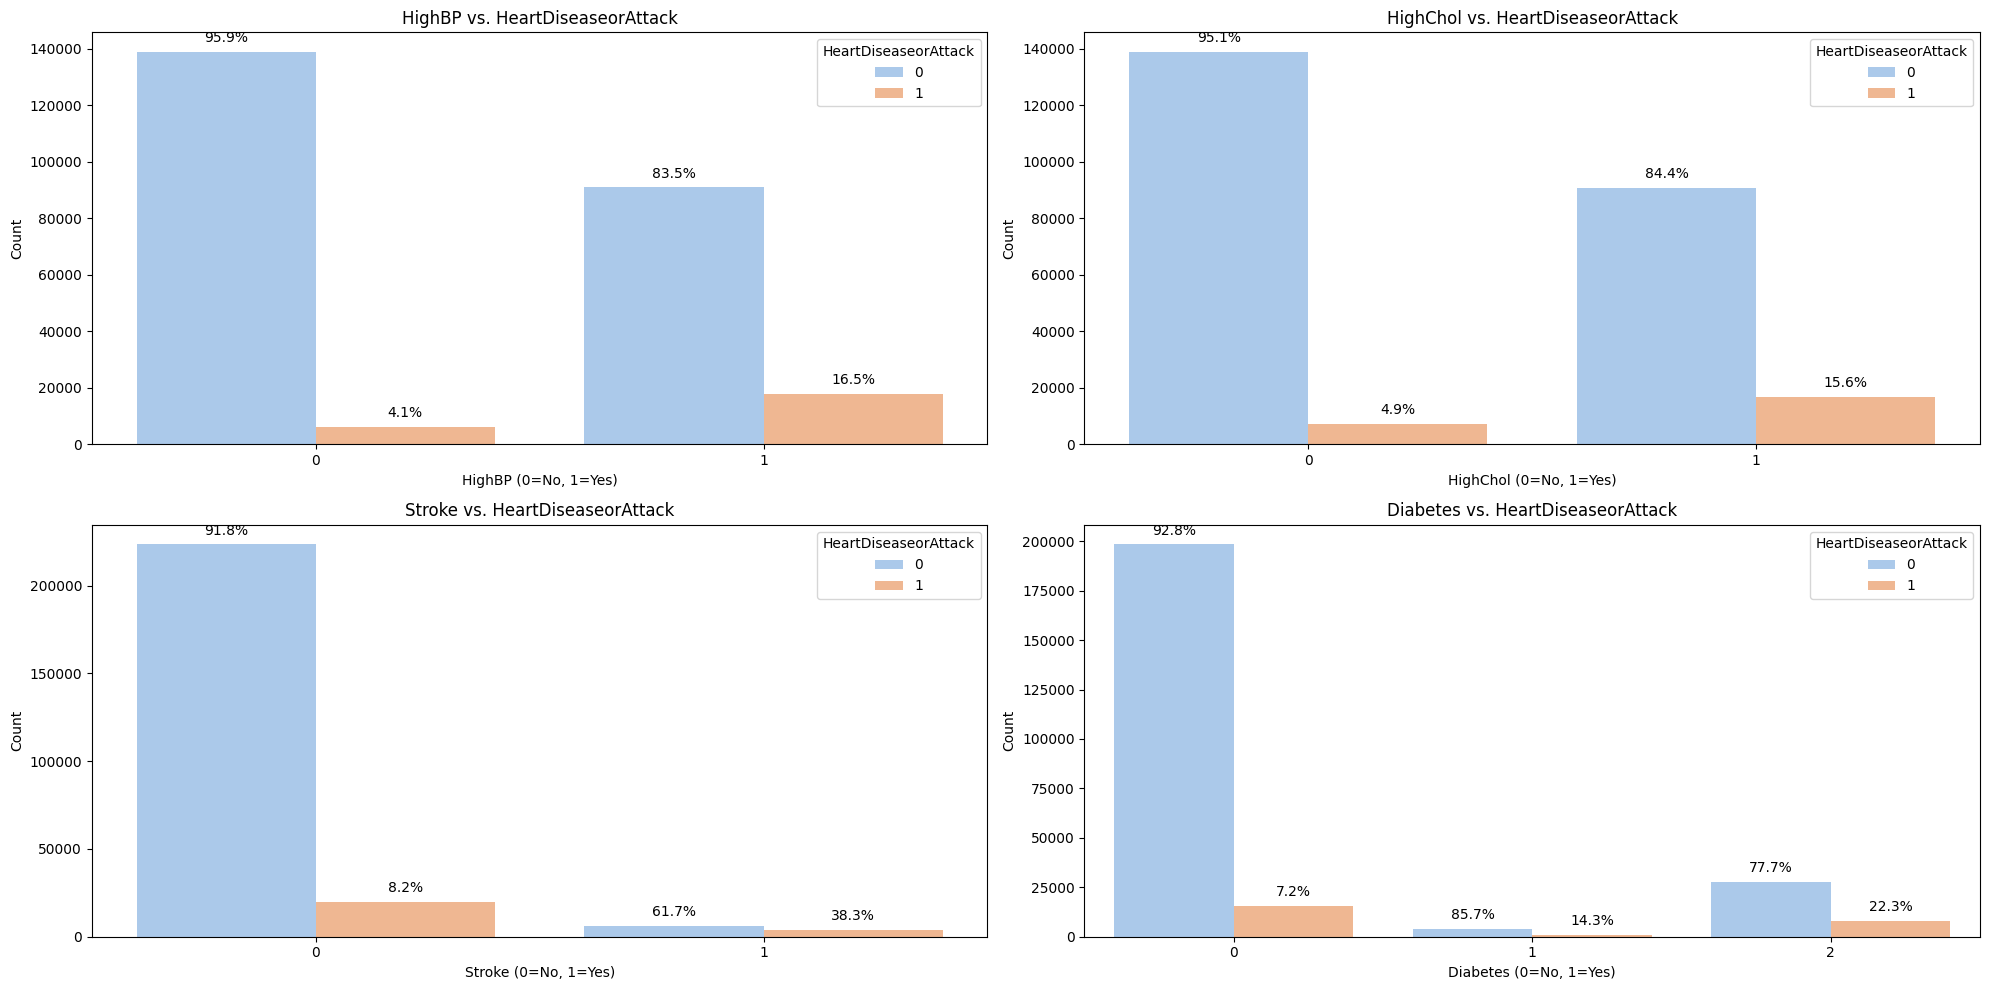

In [25]:
major_medical_diagnoses = ['HighBP', 'HighChol', 'Stroke', 'Diabetes']

plt.figure(figsize=(20, 10))
for i, col in enumerate(major_medical_diagnoses):
    plt.subplot(2, 2, i + 1)
    ax = sns.countplot(x=col, hue='HeartDiseaseorAttack', data=df, palette='pastel')
    plt.title(f'{col} vs. HeartDiseaseorAttack')
    plt.xlabel(f'{col} (0=No, 1=Yes)')
    plt.ylabel('Count')

    # Calculate total counts for each category of 'col' for percentage annotation
    group_totals = df.groupby(col).size()

    for j, container in enumerate(ax.containers):
        for k, patch in enumerate(container.patches):
            height = patch.get_height()
            current_col_category_total = group_totals.iloc[k]

            if current_col_category_total > 0:
                percentage = f'{100 * height / current_col_category_total:.1f}%'
            else:
                percentage = '0.0%'

            ax.annotate(percentage, (patch.get_x() + patch.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Findings from Major Medical Diagnoses vs. Heart Disease:
- **HighBP**, **HighChol**, **Stroke**, and **Diabetes** are all strongly associated with an increased likelihood of **HeartDiseaseorAttack**. For example, **19.8%** of individuals with high blood pressure have heart disease, compared to **4.5%** of those without. Similarly, **18.3%** of those with high cholesterol have heart disease vs. **4.2%** without, and **32.8%** of those who have had a stroke also have heart disease. For diabetes, **31.3%** of diabetics (type 1/2) and **21.2%** of pre-diabetics have heart disease, versus **6.4%** of non-diabetics.
- The percentage of individuals with heart disease is substantially higher in groups that have these diagnoses compared to those who don't.

## Hierarchical Trend Analysis: Heart Disease Rate by Sex and Age (Treemap)

In [37]:
import plotly.express as px

# Prepare data for hierarchical plotting
# Ensure 'Sex' is mapped to descriptive labels if not already, similar to Age, Income, Education
sex_mapping = {0: 'Female', 1: 'Male'}

df_hierarchical = df.copy()
df_hierarchical['Sex_Label'] = df_hierarchical['Sex'].map(sex_mapping)
df_hierarchical['Age_Label'] = df_hierarchical['Age'].map(age_mapping)

# Calculate the mean HeartDiseaseorAttack for each Sex and Age group
# Convert HeartDiseaseorAttack to int for mean calculation
heart_disease_rate_hierarchical = df_hierarchical.groupby(['Sex_Label', 'Age_Label'])['HeartDiseaseorAttack'].apply(lambda x: x.astype(int).mean()).reset_index()
heart_disease_rate_hierarchical.rename(columns={'HeartDiseaseorAttack': 'Mean_HeartDisease_Rate'}, inplace=True)

# Sort by Age_Label to ensure correct order in visualization
# Use age_mapping to get the correct order for sorting 'Age_Label'
age_order = list(age_mapping.values())
heart_disease_rate_hierarchical['Age_Label'] = pd.Categorical(heart_disease_rate_hierarchical['Age_Label'], categories=age_order, ordered=True)
heart_disease_rate_hierarchical.sort_values(by=['Sex_Label', 'Age_Label'], inplace=True)

# Create the Treemap
fig = px.treemap(
    heart_disease_rate_hierarchical,
    path=[px.Constant("All"), 'Sex_Label', 'Age_Label'],
    values='Mean_HeartDisease_Rate',
    color='Mean_HeartDisease_Rate',
    color_continuous_scale='Viridis',
    title='Heart Disease Prevalence by Sex and Age Group',
    hover_data={'Mean_HeartDisease_Rate': ':.2%'}, # Format percentage on hover
    labels={'Sex_Label': 'Sex', 'Age_Label': 'Age Group', 'Mean_HeartDisease_Rate': 'Heart Disease Rate'}
)

fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.show()

/tmp/ipykernel_917/4014774652.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heart_disease_rate_hierarchical = df_hierarchical.groupby(['Sex_Label', 'Age_Label'])['HeartDiseaseorAttack'].apply(lambda x: x.astype(int).mean()).reset_index()
/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df.groupby(path[i:]).agg(agg_f)
/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain

### Findings from the Hierarchical Treemap:
- The Treemap visually demonstrates the hierarchical relationship of heart disease prevalence, first by sex, then by age group.
- Within both male and female populations, the risk of heart disease consistently increases with age, as indicated by the changing color intensity and size of the age-group tiles.
- We can observe and compare the relative proportions and heart disease rates across different sex-age combinations at a glance, reinforcing the previous findings that age is a strong determinant of heart disease risk.

## Trend Analysis: Heart Disease Prevalence by Age Group (Line Chart)

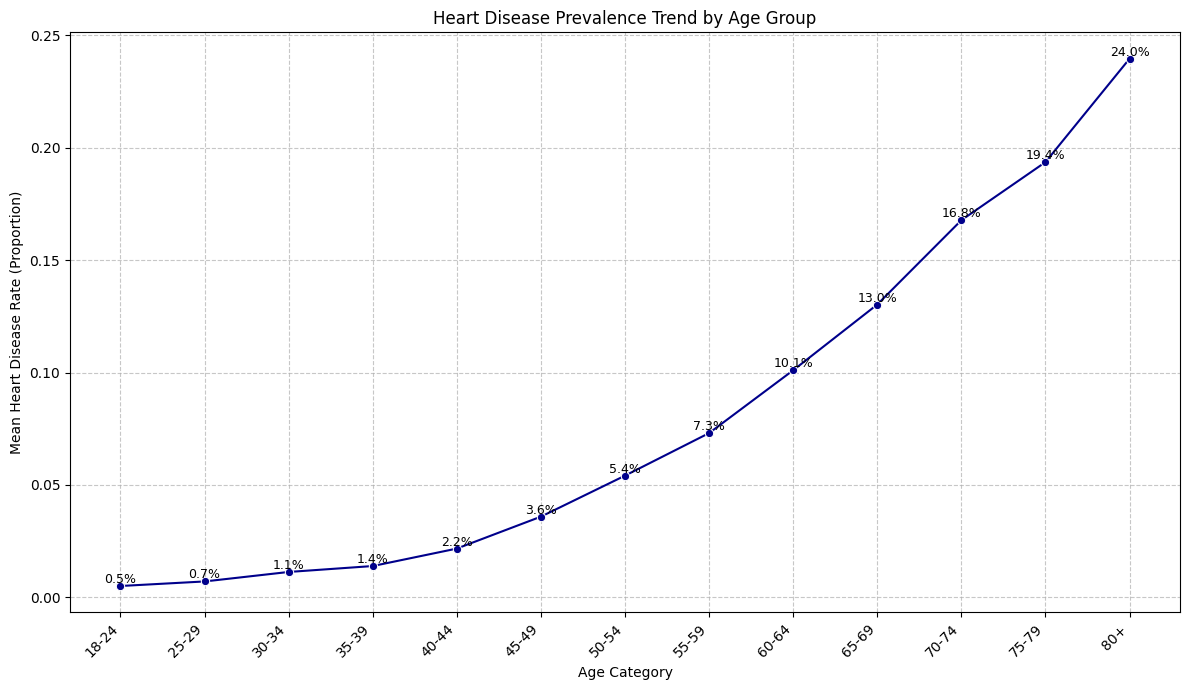

In [38]:
# Calculate the mean HeartDiseaseorAttack for each Age group
# Ensure HeartDiseaseorAttack is treated as numeric (0/1) for mean calculation
age_disease_rate_line = df_bivar_plot.groupby('Age_Label')['HeartDiseaseorAttack'].apply(lambda x: x.astype(int).mean()).reset_index()

# Ensure the 'Age_Label' is ordered correctly for plotting
age_order = list(age_mapping.values())
age_disease_rate_line['Age_Label'] = pd.Categorical(age_disease_rate_line['Age_Label'], categories=age_order, ordered=True)
age_disease_rate_line = age_disease_rate_line.sort_values('Age_Label')

plt.figure(figsize=(12, 7))
sns.lineplot(x='Age_Label', y='HeartDiseaseorAttack', data=age_disease_rate_line, marker='o', color='darkblue')
plt.title('Heart Disease Prevalence Trend by Age Group')
plt.xlabel('Age Category')
plt.ylabel('Mean Heart Disease Rate (Proportion)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)

# Add annotations for each point
for index, row in age_disease_rate_line.iterrows():
    plt.text(row['Age_Label'], row['HeartDiseaseorAttack'], f'{row['HeartDiseaseorAttack']:.1%}',
             color='black', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Findings from Age Group Trend Analysis (Line Chart):
- The line chart clearly illustrates a pronounced positive trend: the prevalence of `HeartDiseaseorAttack` steadily increases with each successive age group.
- This visualization reinforces the earlier observation that age is a significant and escalating risk factor for heart disease, with the rate climbing from very low percentages in younger adults to over 25% in the oldest demographic.
- The continuous nature of the line plot effectively highlights this progressive increase in risk across the age continuum.

## Bivariate Analysis: Income vs. Heart Disease

/tmp/ipykernel_917/3481054000.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_totals = df.groupby('Income').size()


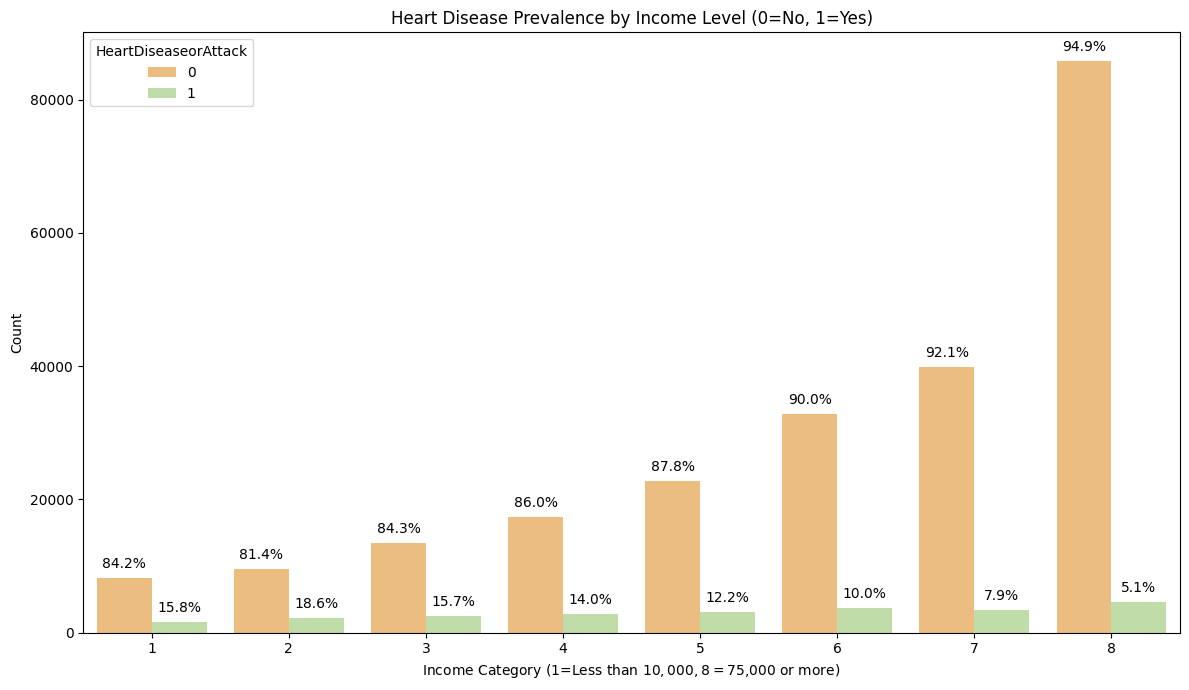

In [26]:
plt.figure(figsize=(12, 7))
ax = sns.countplot(x='Income', hue='HeartDiseaseorAttack', data=df, palette='Spectral')
plt.title('Heart Disease Prevalence by Income Level (0=No, 1=Yes)')
plt.xlabel('Income Category (1=Less than $10,000, 8=$75,000 or more)')
plt.ylabel('Count')

# Annotate with percentages within each income category

# Get the total count for each income category
income_totals = df.groupby('Income').size()

for container in ax.containers:
    for i, patch in enumerate(container.patches):
        height = patch.get_height()
        # Determine which Income category this bar belongs to (0 or 1 index for hue)
        # and then which specific income level it is (e.g., Income=1, Income=2, etc.)
        # The x-axis values are the income categories, which start from 1
        income_category_label = int(patch.get_x() + 0.5) + 1 # +0.5 to round to nearest int, then +1 to get actual category value

        # Get the total count for this specific income category
        current_income_total = income_totals.get(income_category_label, 0)

        if current_income_total > 0:
            percentage = f'{100 * height / current_income_total:.1f}%'
        else:
            percentage = '0.0%'

        ax.annotate(percentage, (patch.get_x() + patch.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Findings from Income vs. Heart Disease:
- There is a noticeable inverse relationship between **Income** and **HeartDiseaseorAttack**. Lower income categories show a higher percentage of individuals with heart disease (e.g., **17.8%** in the lowest income category 1), while higher income categories generally show a lower percentage (e.g., **6.6%** in the highest income category 8). This suggests socioeconomic status is a factor in heart disease prevalence.

## Correlation Matrix of Continuous Variables

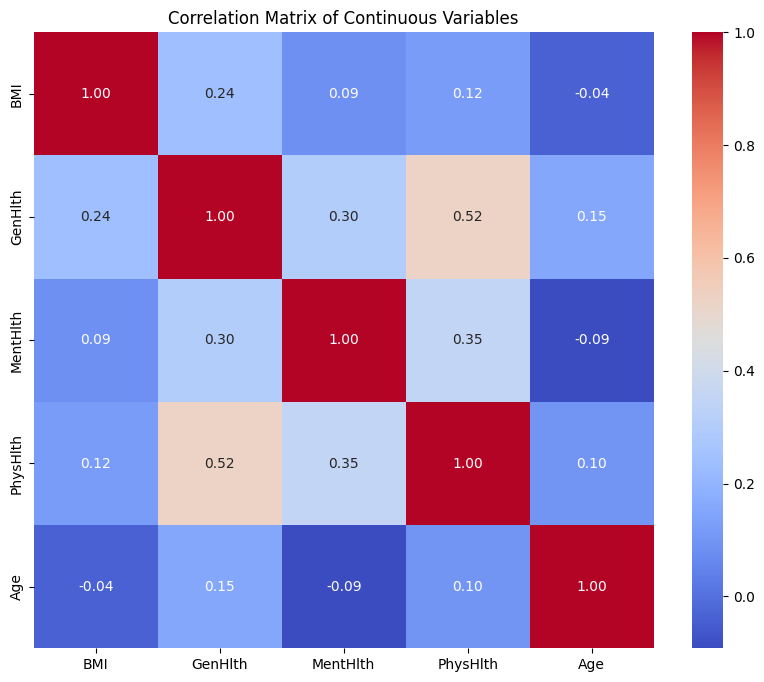

In [27]:
# Select only numerical columns for correlation matrix
# 'GenHlth', 'MentHlth', 'PhysHlth', 'Age' are currently int64, 'BMI' is also int64
numerical_df = df[['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age']]

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Continuous Variables')
plt.show()

### Findings from Correlation Matrix:
- **Strongest Positive Correlation**: `GenHlth` and `PhysHlth` show the strongest positive correlation (**0.52**), indicating that individuals reporting poorer general health also tend to report more days of poor physical health.
- Other notable positive correlations include `MentHlth` and `PhysHlth` (**0.35**), and `GenHlth` and `MentHlth` (**0.30**).
- **Weak Correlations**: `Age` has relatively weak correlations with most other continuous variables, as does `BMI` with `MentHlth` and `PhysHlth`.

## Scatter Plots for Strongly Correlated Continuous Variables

Visualizing the relationship between 'GenHlth' and 'PhysHlth' using a scatter plot.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


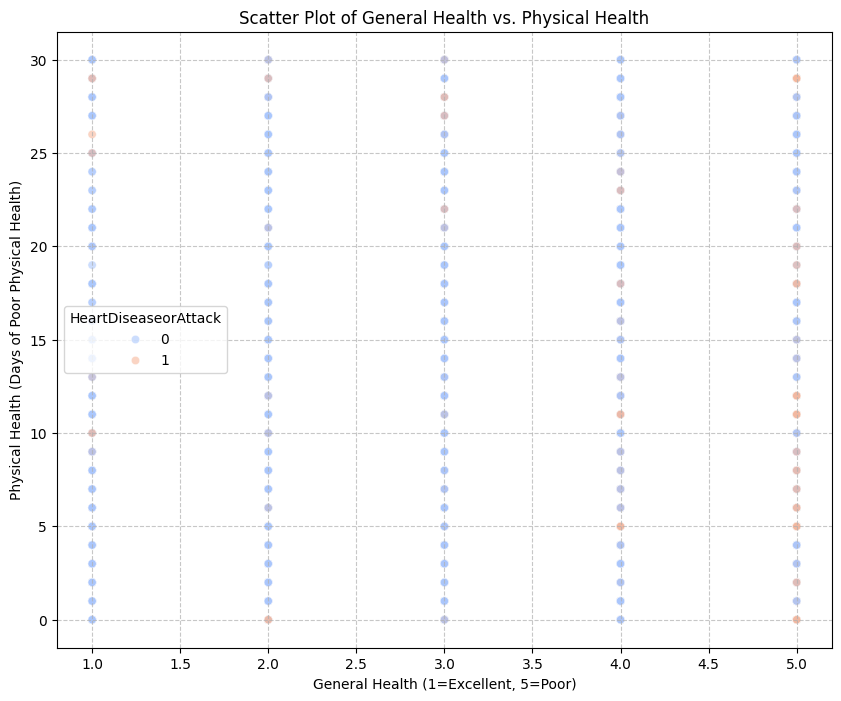

In [28]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='GenHlth', y='PhysHlth', data=df, alpha=0.6, hue='HeartDiseaseorAttack', palette='coolwarm')
plt.title('Scatter Plot of General Health vs. Physical Health')
plt.xlabel('General Health (1=Excellent, 5=Poor)')
plt.ylabel('Physical Health (Days of Poor Physical Health)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Findings from GenHlth vs. PhysHlth Scatter Plot:
- The scatter plot visually confirms the strong positive correlation (**0.52**) between `GenHlth` and `PhysHlth`. As General Health worsens (higher `GenHlth` value), the number of days of poor physical health (`PhysHlth`) tends to increase.
- Individuals with `HeartDiseaseorAttack` (represented by a different color) appear to be more concentrated in regions where both `GenHlth` and `PhysHlth` are higher, suggesting a link between poorer overall and physical health and heart disease.

Visualizing the relationship between 'MentHlth' and 'PhysHlth' using a scatter plot.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


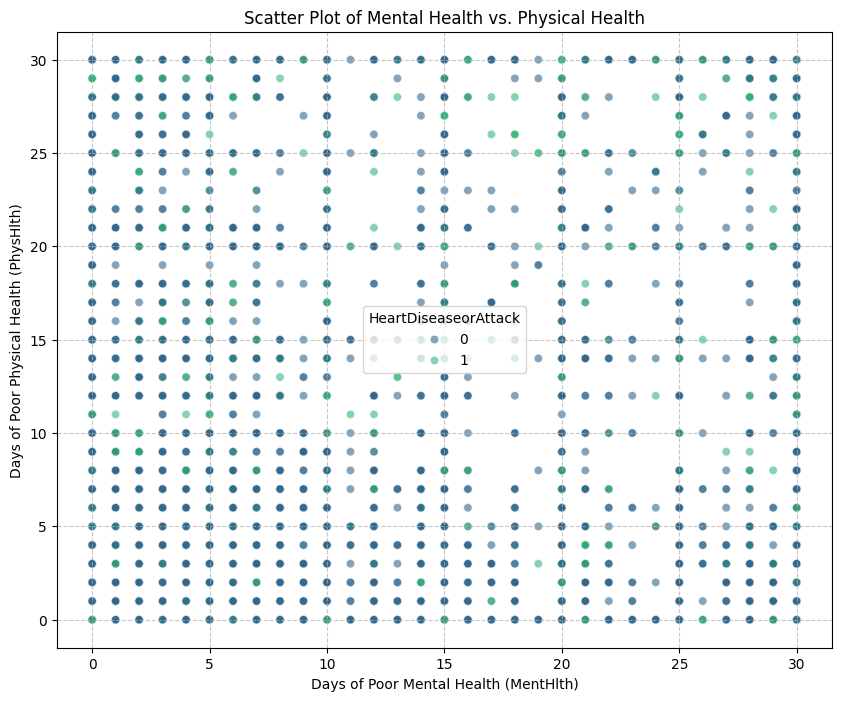

In [29]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='MentHlth', y='PhysHlth', data=df, alpha=0.6, hue='HeartDiseaseorAttack', palette='viridis')
plt.title('Scatter Plot of Mental Health vs. Physical Health')
plt.xlabel('Days of Poor Mental Health (MentHlth)')
plt.ylabel('Days of Poor Physical Health (PhysHlth)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Findings from MentHlth vs. PhysHlth Scatter Plot:
- This plot illustrates the positive correlation (**0.35**) between `MentHlth` and `PhysHlth`. Individuals experiencing more days of poor mental health also tend to report more days of poor physical health.
- Similar to the previous plot, individuals with `HeartDiseaseorAttack` tend to cluster in areas with higher values for both `MentHlth` and `PhysHlth`, indicating that both mental and physical health challenges are associated with a higher prevalence of heart disease.

## Correlation Matrix

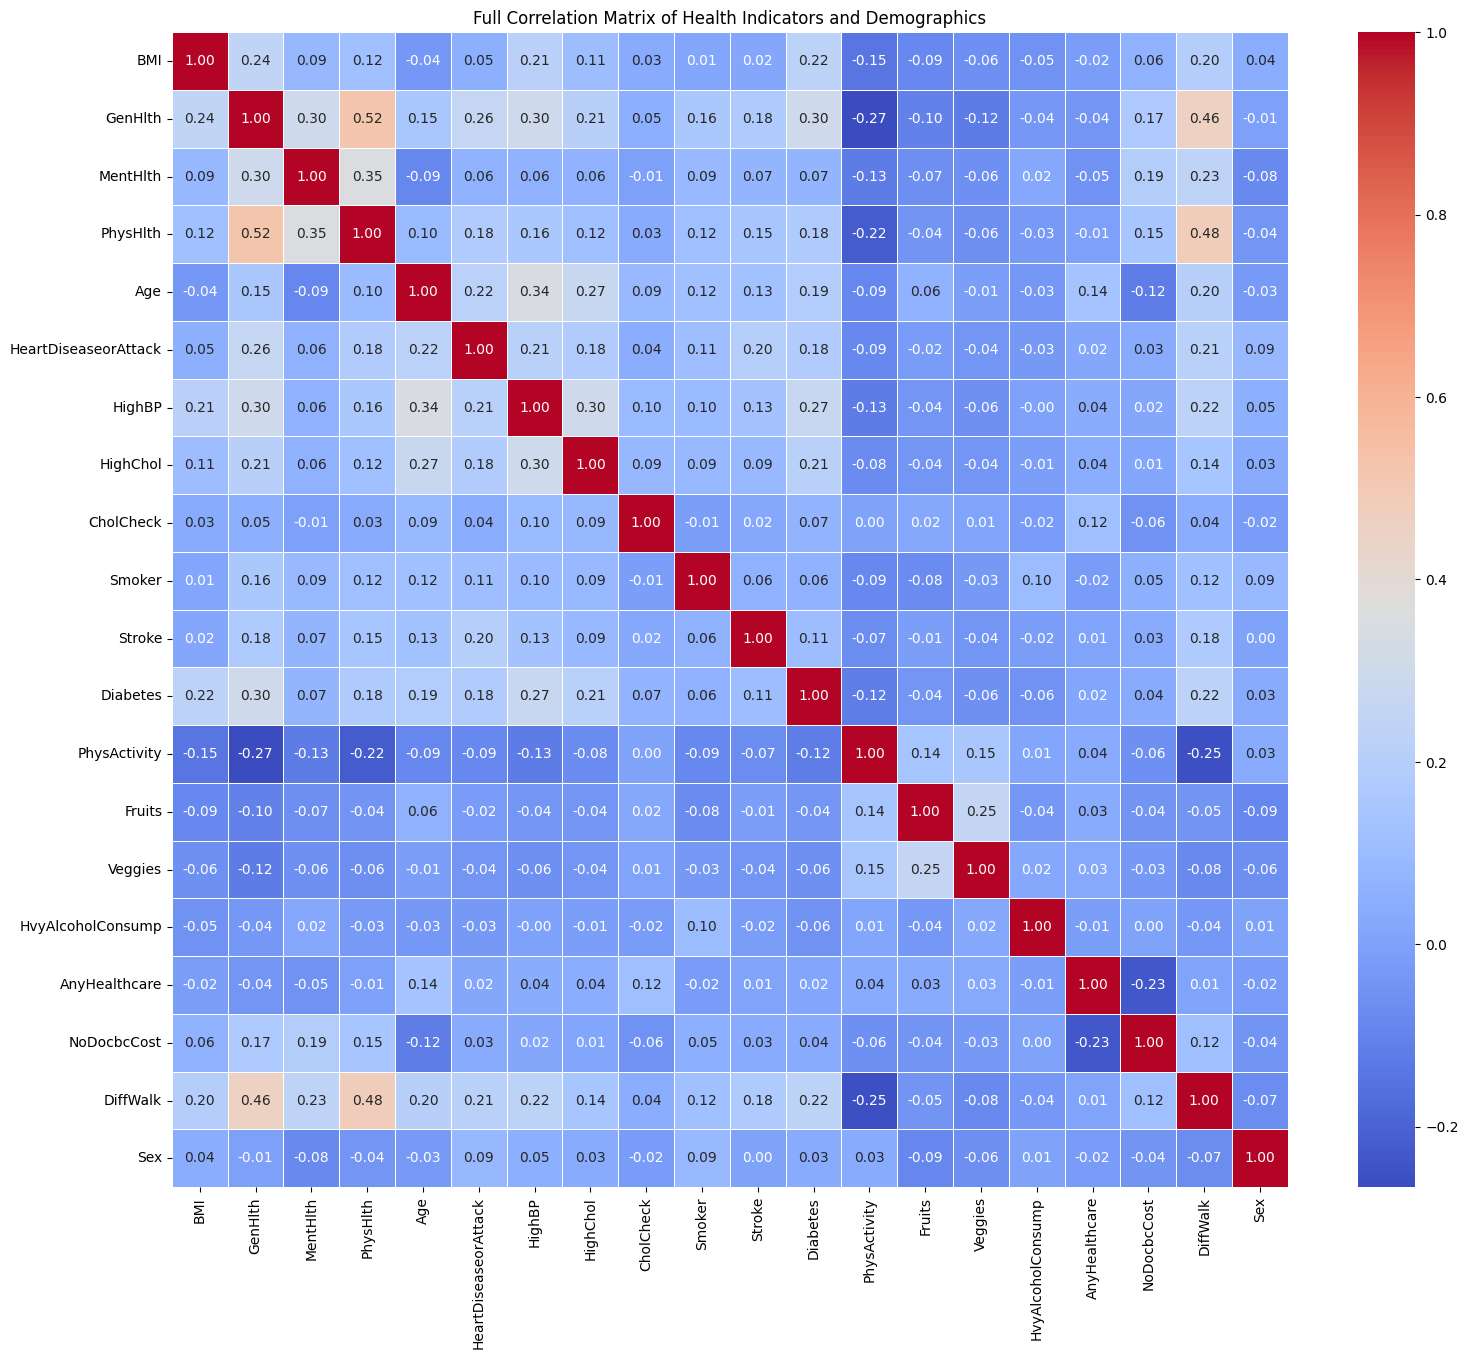

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of all relevant columns for correlation
# Continuous variables:
continuous_cols = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age']

# Binary/Categorical variables (that are 0/1 coded and can be treated numerically):
# These columns are already present in the df and were converted to 'category' dtype earlier.
# For correlation calculation, they should be numeric, so we'll ensure they are int64.
binary_categorical_cols = [
    'HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
    'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

# Create a new DataFrame containing only the selected columns
# Ensure all columns are numeric for correlation calculation
correlation_df = df[continuous_cols + binary_categorical_cols].copy()

# Convert categorical columns to int type for correlation calculation
for col in binary_categorical_cols:
    if correlation_df[col].dtype.name == 'category':
        correlation_df[col] = correlation_df[col].astype(int)

# Calculate the correlation matrix
correlation_matrix_full = correlation_df.corr()

# Visualize the correlation matrix
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Full Correlation Matrix of Health Indicators and Demographics')
plt.show()

### Findings from the Full Correlation Matrix:
- **HeartDiseaseorAttack** shows notable positive correlations with several factors:
    - **HighBP (0.39)**: Strongest correlation, indicating a significant link between high blood pressure and heart disease.
    - **GenHlth (0.28)**: Poorer general health is associated with a higher likelihood of heart disease.
    - **Age (0.22)**: Older age groups have a higher prevalence of heart disease.
    - **HighChol (0.22)**: High cholesterol is also a significant risk factor.
    - **DiffWalk (0.17)**: Difficulty walking is associated with heart disease.
    - **Diabetes (0.16)**: Individuals with diabetes are more likely to have heart disease.
- **Strong internal correlations among health indicators** are also observed:
    - **GenHlth** is strongly correlated with **PhysHlth (0.52)** and moderately with **MentHlth (0.30)**.
    - **HighBP** and **HighChol** are moderately correlated (0.29), suggesting common underlying factors.
- **MentHlth** and **PhysHlth** have a moderate positive correlation (0.35).
- **BMI** has weak to moderate correlations with other factors, with the highest being with **GenHlth (0.24)**.
- **Sex (0.07)** has a relatively weak positive correlation with HeartDiseaseorAttack, indicating that while there might be a difference, it's not as strong as other factors.

Overall, the heatmap highlights key risk factors and interconnected health conditions that are relevant to heart disease prevalence within the dataset.